# Amazon Product Review Dataset Analysis 

In [3]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
# !pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf



# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA

# Progress Tracking

# !pip install tqdm 
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 0

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [4]:
#DONE -> install pyarrow into conda environment (for parquet files)
# !conda install pyarrow -y

# Loading Dataset (only first 500k rows)

In [5]:
# #CONVERT INTO DATAFRAME first with pd.read_json (only first 500k rows)

#--> ONLY ONCE DONE 
# url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz"

# df = pd.read_json(
#     url,
#     lines=True,
#     compression="gzip",
#     nrows=500000
# )

In [6]:
#download locally parquet (--> ONLY ONCE DONE)

# df.to_parquet("electronics_500k.parquet") 

In [7]:
#LOAD the df 
df = pd.read_parquet("electronics_500k.parquet")
df.head(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True
1,1,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True
2,5,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True


In [8]:
#CONVERT meta file into df called "meta" (--> ONLY ONCE DONE)

# url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Electronics.jsonl.gz"
# meta = pd.read_json(url, lines=True, compression='gzip', nrows=500000)

In [9]:
# download locally meta (--> ONLY ONCE DONE)
# meta_small = meta[
#     ["main_category", "title", "average_rating", "rating_number", "price", "categories", "parent_asin", "bought_together"]
# ].copy()

# meta_small["price"] = pd.to_numeric(meta_small["price"], errors="coerce")

# meta_small.to_parquet("meta_electronics_500k.parquet", index=False)

In [10]:
#Load meta df
meta = pd.read_parquet("meta_electronics_500k.parquet")
meta.head(3)

,main_category,title,average_rating,rating_number,price,categories,parent_asin,bought_together
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,NaN,"[Electronics, Television & Video, Video Glasses]",B00MCW7G9M,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,NaN,"[Electronics, Television & Video, Accessories,...",B00YT6XQSE,NaN
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,19.99,"[Electronics, Computers & Accessories, Laptop ...",B07SM135LS,NaN


In [11]:
display(df.columns, meta.columns)

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

Index(['main_category', 'title', 'average_rating', 'rating_number', 'price',
       'categories', 'parent_asin', 'bought_together'],
      dtype='object')

# 1) EDA of Merged Dataset: PRE-PROCESSING

### Merging duplicate columns across both datasets
- parent_asin = "umbrella" code for group product VARIATIONS e.g. size, color
- asin = 10-character code for ANY product

In [12]:
#Confirm if parent_asin matches WITHIN BOTH df and meta df 
display(df['parent_asin'].isin(meta['parent_asin']).mean()) #only 51% have same parent_asin

#MERGE using parent_asin as identifier
df_merged = df.merge(meta, how='left', on="parent_asin")
df_merged.columns

np.float64(0.519946)

Index(['rating', 'title_x', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'main_category',
       'title_y', 'average_rating', 'rating_number', 'price', 'categories',
       'bought_together'],
      dtype='object')

In [13]:
# #check if duplicate column names have same info
#     display((df_merged['title_x']==df_merged['title_y']).mean())
#     display((df_merged['images_x']==df_merged['images_y']).mean())
# #now names are gone after renaming them below 

#No, so feature engineer (rename them)
df_merged = df_merged.rename(columns= {
    'title_x' : 'review_title',
    'title_y': 'product_title',
    'images_x' : 'review_images',
    'images_y' : 'product_images',
    'rating_number' : 'rating_count'
})
df_merged.columns

Index(['rating', 'review_title', 'text', 'images', 'asin', 'parent_asin',
       'user_id', 'timestamp', 'helpful_vote', 'verified_purchase',
       'main_category', 'product_title', 'average_rating', 'rating_count',
       'price', 'categories', 'bought_together'],
      dtype='object')

### FEATURE DESCRIPTIONS

- Rating = 0-5 star of product given in review
- Timestamp = when wrote review
- Helpful vote = how many people found the review helpful
- Main_category = what category of item bought, helps analysis
- Product_title = unique product name 
- Rating_count = HOW MANY TOTAL RATINGS FOR THIS ITEM
- Average_rating = averaged rating for this item over 1-1000+ reviews
- Price = cost
- asin = individual product LISTINGS (can be diff colors, sellers, etc)
- parent_asin = product family (even if diff colors, etc.)
- user_id = unique customers


In [14]:
#check if column names make sense 
df_merged

,rating,review_title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,main_category,product_title,average_rating,rating_count,price,categories,bought_together
0,3,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Cell Phones & Accessories,Edifier P841 Comfortable Noise Isolating Over-...,4.0,423.0,45.99,"[Electronics, Headphones, Earbuds & Accessorie...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,1,Bad tablet,Only it worked 6 months and then I never use a...,[],B00V49LV86,B00V49LV86,AHF67IHUZRPOOBSEEWHTWVP3CKYA,2018-11-16 22:29:34.194,0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499996,5,Great TV,Perfect for me,[],B07CL4GLQW,B0BTPBBL52,AGEHNDVTNOMWTHADWWGVOSJD6FQQ,2020-08-11 21:13:16.209,0,True,All Electronics,SAMSUNG 32-inch Class LED Smart FHD TV 1080P (...,4.6,12802.0,217.90,"[Electronics, Television & Video, Televisions,...",NaN
499997,4,Great Back Pack,I wish they would have put tassels on all the ...,[],B077RJCYZC,B077RFRSD9,AGEHNDVTNOMWTHADWWGVOSJD6FQQ,2020-01-06 15:29:56.337,0,True,AMAZON FASHION,"UNIWALK Canvas Laptop Backpack, Waterproof Vin...",4.7,805.0,33.99,"[Electronics, Computers & Accessories, Laptop ...",NaN
499998,5,Great sound,Better than previous earbuds by far. Good volu...,[],B00JE08H8O,B09HLGPB3D,AGEHNDVTNOMWTHADWWGVOSJD6FQQ,2019-04-17 17:33:37.474,0,True,Home Audio & Theater,Sony MDRXB50AP Extra Bass Earbud Headphones/He...,4.5,21632.0,NaN,"[Electronics, Headphones, Earbuds & Accessorie...",NaN


In [15]:
#Summary Statistics 

display(
    df_merged.info(),
    df_merged.describe()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             500000 non-null  int64         
 1   review_title       500000 non-null  object        
 2   text               500000 non-null  object        
 3   images             500000 non-null  object        
 4   asin               500000 non-null  object        
 5   parent_asin        500000 non-null  object        
 6   user_id            500000 non-null  object        
 7   timestamp          500000 non-null  datetime64[ns]
 8   helpful_vote       500000 non-null  int64         
 9   verified_purchase  500000 non-null  bool          
 10  main_category      258357 non-null  object        
 11  product_title      259973 non-null  object        
 12  average_rating     259973 non-null  float64       
 13  rating_count       259973 non-null  float64 

None

,rating,timestamp,helpful_vote,average_rating,rating_count,price,bought_together
count,500000.000000,500000,500000.000000,259973.000000,2.599730e+05,172904.000000,0.0
mean,4.230672,2018-04-19 19:20:28.269936896,1.431662,4.349765,2.730725e+04,62.555129,NaN
min,1.000000,1998-03-03 12:17:02,0.000000,1.000000,1.000000e+00,0.010000,NaN
25%,4.000000,2016-02-06 14:09:35.750000128,0.000000,4.200000,3.650000e+02,12.990000,NaN
50%,5.000000,2018-08-29 00:19:04.954000128,0.000000,4.400000,2.284000e+03,23.500000,NaN
75%,5.000000,2020-10-29 18:15:47.715750144,0.000000,4.600000,1.324000e+04,52.990000,NaN
max,5.000000,2023-03-20 00:47:02.053000,8722.000000,5.000000,1.034896e+06,24996.990000,NaN
std,1.277176,NaN,27.729206,0.367597,8.743607e+04,164.343042,NaN


In [16]:
#How many unique products, group of products, and user_ids
display(df_merged['asin'].nunique(),    #individual product LISTINGS (can be diff colors, sellers, etc)
        df_merged['parent_asin'].nunique(),     #product family (even if diff colors, etc.)
        df_merged['user_id'].nunique(),         #unique customers
        df_merged['product_title'].nunique()    #unique product names
         )

206028

177727

94898

74571

- About 200k individual product listings, 177k groups of products, 94k individual buyers, 74k different products

In [17]:
#explore individual features
df_merged['product_title'].duplicated().sum() #because 74k+420k=500k total rows

np.int64(425428)

In [18]:
#PREPROCESSING HERE


#1a) Handling Missing Values

    #product_title has 74k unique, but is COUNTING NaN as duplicates, (check duplicates EXCLUDING NaN)
df_merged[df_merged['product_title'].notna()]['product_title'].duplicated().sum()
    #thus = 185k products reordered 

np.int64(185402)

In [19]:
# 1b) MANY product titles are NaN, parent_asin = B01G8JO5F2,  so deal with this 
df_merged[df_merged['product_title'].isna()].shape  #240k named NaN 

#CHANGE NaN product titles to 'Unknown Product'
df_merged['product_title'] = df_merged['product_title'].fillna('Unknown Product')

df_merged['product_title'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 500000 entries, 0 to 499999
Series name: product_title
Non-Null Count   Dtype 
--------------   ----- 
500000 non-null  object
dtypes: object(1)
memory usage: 3.8+ MB


In [20]:
#DONE ALREADY ---> 1c) bought_together = all values are NaN
# df_merged = df_merged.drop(columns=['bought_together'])

In [250]:
#2) Categorical Variables Consistent Formats

    #Price is dtype object (many values NaN, None)
    #change to numeric, DO NOT REPLACE WITH MEDIAN VALUE bc fake prices that distort product metadata
        #during analysis - leave out n/a prices
df_merged['price']=pd.to_numeric(df_merged['price'],errors='coerce')
df_merged['price'].dtype


/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_58720/1799119152.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['price']=pd.to_numeric(df_merged['price'],errors='coerce')


dtype('float64')

In [251]:
#3) Standardize Units
    #can create new column for like review_year for eda -> using .dt.year 

#4) Remove Duplicates based on SUBSET -> same user, same, product, same timestamp
df_merged=df_merged.drop_duplicates(subset=['user_id', 'asin', 'timestamp'])
df_merged.shape

(499010, 19)

## 1DF) IMPORTANT: df_merged is for REVIEW analysis e.g. firestickTV will appear 10,000 or etc times which will bias PRODUCT analysis like if graph prices

## 2DF) THUS = make new df_prod dataset with only ONE product per row 
- can just drop duplicate for parent_asin, BECAUSE already an average_rating column, so no matter what row it picks for that single product it will not affect ratings

In [249]:
#create clean product dataset 
df_prod = df_merged.drop_duplicates('parent_asin')
df_prod.shape

#FOR ANALYSIS = MAKE SUBSETS with no NaN (e.g. df_price = df_prod.dropna(subset=['price']) )

(177727, 19)

### 3DF) NEW SUMMARY DF to look at average ratings per product group

In [252]:
#create NEW df_review_summary = for each parent_asin aggregates
    #mean rating, sum helpful_votes, review counts 
df_review_summary = df_merged.groupby('parent_asin').agg({
    'rating':'mean',
    'helpful_vote':'sum',
    'user_id':'count'
}).rename(columns={'user_id':'review_count'}).reset_index()
df_review_summary

,parent_asin,rating,helpful_vote,review_count
0,0060897082,5.00,2,1
1,0062970704,4.92,2,25
2,0140194614,4.00,0,1
3,0140543635,5.00,0,1
4,0224073087,5.00,0,1
...,...,...,...,...
177722,B0CHRMBHJK,5.00,61,1
177723,B0CHRRCRMQ,5.00,1,1
177724,B0CHYSTK6M,3.00,0,1
177725,B0CJ26JLWQ,5.00,1,1


# SUMMARY OF df_ variables


In [253]:
print("df_merged:", df_merged.shape)
print("df_prod:", df_prod.shape)

df_merged: (499010, 19)
df_prod: (177727, 19)


# 2) EDA of Dataset: Univariate Analysis 

In [254]:
#from before 
#How many unique products, group of products, and user_ids
display(df_merged['asin'].nunique(),    #individual product LISTINGS (can be diff colors, sellers, etc)
        df_merged['parent_asin'].nunique(),     #product family (even if diff colors, etc.)
        df_merged['user_id'].nunique(),         #unique customers
        df_merged['product_title'].nunique()    #unique product names
         )

206028

177727

94898

74572

,product_title,count
0,"Fire TV Stick with Alexa Voice Remote, streami...",1744
1,Echo Dot (2nd Generation) - Smart speaker with...,1515
2,"Fire Tablet with Alexa, 7"" Display, 16 GB, Blu...",1212
3,"Panasonic ErgoFit Wired Earbuds, In-Ear Headph...",1061
4,Edifier P841 Comfortable Noise Isolating Over-...,890
5,"Echo Dot (3rd Gen, 2018 release) - Smart speak...",843
6,"OontZ Angle 3 Bluetooth Speaker, Portable Wire...",643
7,"Amazon Smart Plug, for home automation, Works ...",639
8,TOZO T10 Bluetooth 5.3 Wireless Earbuds with W...,551
9,SanDisk Ultra 32GB microSDHC UHS-I Card with A...,536


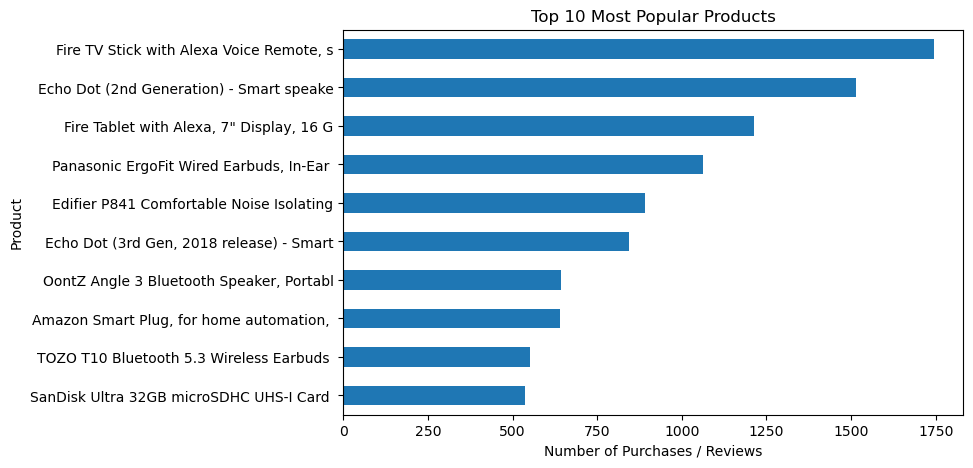

In [255]:
#1) PURCHASE POPULARITY         USE THIS GRAPH 

    #show products with MOST PURCHASES 
# Filter the dataframe first, then count
popular_products = df_merged[df_merged['product_title'] != 'Unknown Product']
display(popular_products['product_title'].value_counts().reset_index().head(10))   
# df_merged.groupby('product_title').size().sort_values(ascending=False)    #this does same thing

# plot barh graph
top_products = popular_products['product_title'].value_counts().head(10)
top_products.index = top_products.index.str.slice(0,40)
plt.figure(figsize=(8,5))

top_products.sort_values().plot(kind='barh')

plt.xlabel("Number of Purchases / Reviews")
plt.ylabel("Product")
plt.title("Top 10 Most Popular Products")

plt.show()
    

### Example KECC macbook case -> has most product variations(asin) = 43, purchased 53 times 

In [27]:
df_merged[df_merged['parent_asin']=='B0BTZDHJXY'].count()


rating               53
review_title         53
text                 53
images               53
asin                 53
parent_asin          53
user_id              53
timestamp            53
helpful_vote         53
verified_purchase    53
main_category        53
product_title        53
average_rating       53
rating_count         53
price                53
categories           53
bought_together       0
dtype: int64

Text(0, 0.5, 'Number of Reviews')

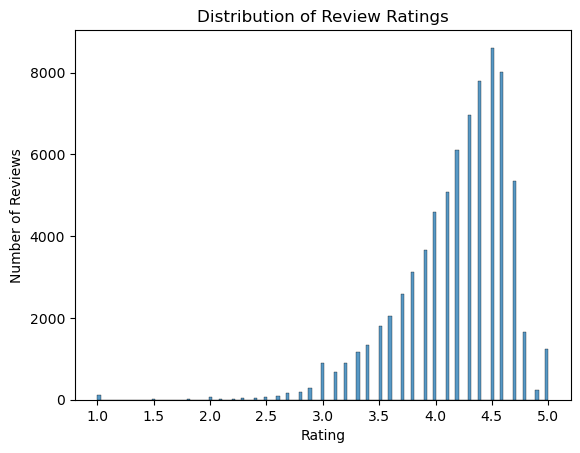

In [28]:
#2) Distribution of RATINGS for all products no variations
    #did NOT use df_merged because has duplicate average ratings b/c multiple rows per product
sns.histplot(df_prod['average_rating'])     #here bc df_prod only uses 1 product per row = avg_rating same as just rating
plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

chatgpt The rating distribution is strongly left-skewed, with the majority of reviews receiving four or five stars. This pattern is common in online review platforms where satisfied customers are more likely to leave reviews.


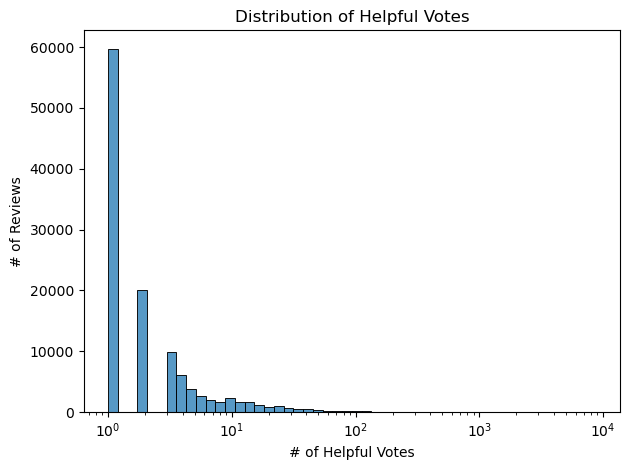

In [29]:
#3) Distribution of Helpful Votes 
sns.histplot(df_merged['helpful_vote'], bins=50, log_scale=True)
plt.title('Distribution of Helpful Votes')
plt.xlabel('# of Helpful Votes')
plt.ylabel('# of Reviews')
plt.tight_layout()

verified_purchase
True     0.889471
False    0.110529
Name: proportion, dtype: float64

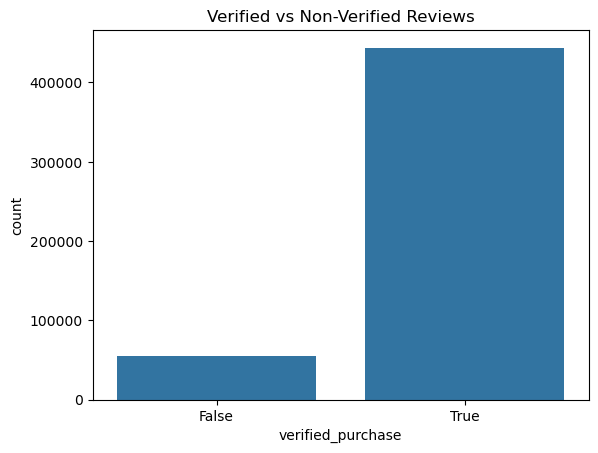

In [30]:
#4) how many verified and nonverified reviews are in dataset
sns.countplot(x='verified_purchase', data=df_merged)
plt.title("Verified vs Non-Verified Reviews")

df_merged['verified_purchase'].value_counts(normalize=True)

Text(0.5, 1.0, 'Distribution of Product Average Ratings')

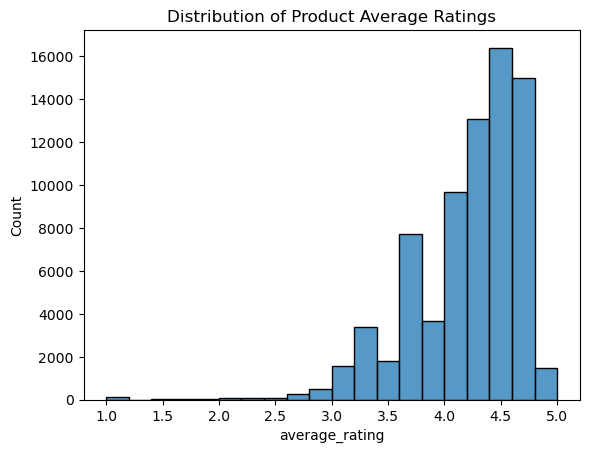

In [31]:
#5) USE THIS PRODUCT AVERAGE RATINGS 
sns.histplot(df_prod['average_rating'], bins=20)
plt.title("Distribution of Product Average Ratings")

chatgpt Product average ratings are concentrated at the higher end of the scale, indicating generally positive customer satisfaction among electronics products.

count    7.490700e+04
mean     1.446829e+03
std      8.936426e+03
min      1.000000e+00
25%      5.100000e+01
50%      2.000000e+02
75%      7.750000e+02
max      1.034896e+06
Name: rating_count, dtype: float64

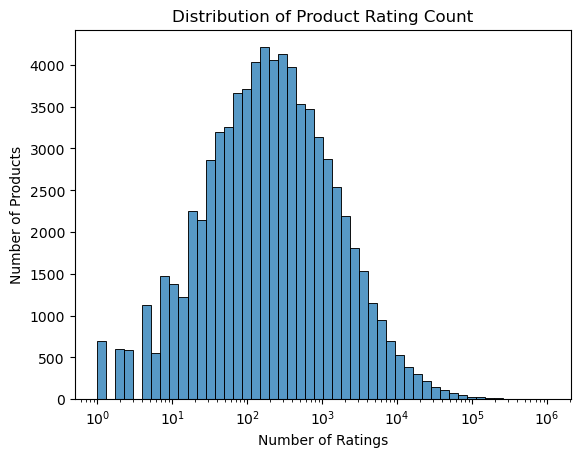

In [32]:
#6) how many ratings does each product receive MAYBE USE THIS GRAPH 
sns.histplot(df_prod['rating_count'], bins=50, log_scale=True);
plt.title('Distribution of Product Rating Count')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Products')

df_prod['rating_count'].describe()

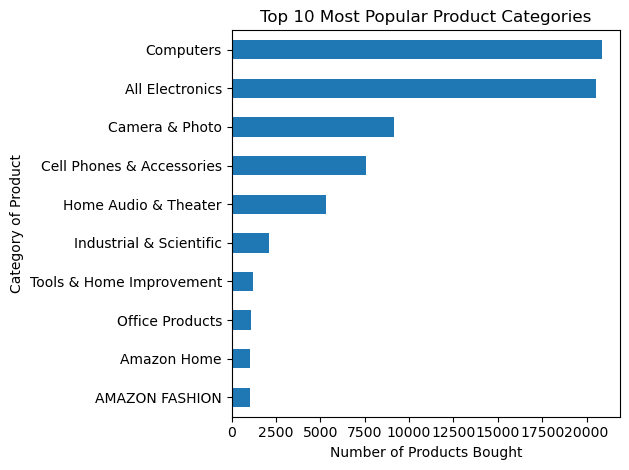

In [33]:
#7) distribution of highest categories that products are bought 
df_prod['main_category'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Most Popular Product Categories')
plt.ylabel('Category of Product')
plt.xlabel('Number of Products Bought')
plt.gca().invert_yaxis()
plt.tight_layout()

In [34]:
df_prod[['average_rating','rating_count','price']].describe()

,average_rating,rating_count,price
count,74907.000000,7.490700e+04,39800.000000
mean,4.180640,1.446829e+03,74.527847
std,0.478745,8.936426e+03,238.606273
min,1.000000,1.000000e+00,0.010000
25%,3.900000,5.100000e+01,12.910000
50%,4.300000,2.000000e+02,22.880000
75%,4.500000,7.750000e+02,57.850000
max,5.000000,1.034896e+06,24996.990000


/opt/anaconda3/envs/MODB2/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='rating'>

<Axes: xlabel='rating'>

/opt/anaconda3/envs/MODB2/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


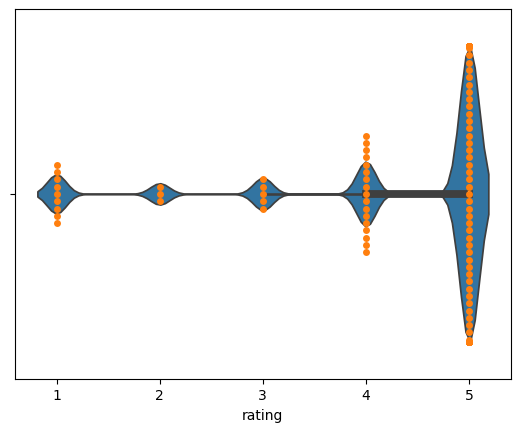

In [35]:
#violin plot of ratings, swarm plot of ratings 
display(
sns.violinplot(x=df_merged['rating']),
sns.swarmplot(x=df_merged['rating'].sample(100))
)

In [36]:
# Histograms, Bar Charts

#box plot, kde, swarm, violin plots

#Identify Distributions, skewed, binomial ex) use log transformation instead

#Summary Statistics mean, med, mode

#Detect Extreme values

# 3) EDA of Dataset: Bivariate Analysis 

In [37]:
#0) USE THIS GRAPH which products highest ratings (n>100)
high_review = df_prod[df_prod['rating_count'] >= 100]
top_rated = (
    high_review.sort_values('average_rating', ascending=False)[['product_title','average_rating','rating_count']].head(10).reset_index()
)

top_rated

,index,product_title,average_rating,rating_count
0,391078,"BOLOXA S10 True Wireless Headphones Earbuds,Pink",5.0,143.0
1,117942,WiFi Extender Internet Signal Booster and Ampl...,5.0,1033.0
2,41165,occiam Wireless Earbuds Bluetooth Headphones V...,5.0,173.0
3,391079,CAPOXO Wireless Earbuds Bluetooth 5.3 Headphon...,5.0,237.0
4,183233,"Noctua NH-U12A, Disipador de CPU de Gran Calid...",4.9,3063.0
5,50720,Mix Hero Wireless Earbuds Bluetooth 5.0 Headph...,4.9,247.0
6,193908,"WiFi Extender, Finngamo 1200Mbps WiFi Extender...",4.9,145.0
7,318250,"Noctua NH-D12L, Low-Height Dual-Tower CPU Cool...",4.9,238.0
8,467453,Asafe Hard Case Compatible with SELPHY CP1300 ...,4.9,143.0
9,490605,"Apple Watch Series 5 (GPS, 40mm) - Gold Alumin...",4.9,286.0


In [38]:
#1) for each product, how many DIFFERENT LISTINGS/variations (diff colors, etc.) are there 
display(
    df_merged.groupby('parent_asin')['asin'].nunique().sort_values(ascending=False).head(10),   #only gives identifier code
    df_merged.groupby('product_title')['asin'].nunique().sort_values(ascending=False).head(10) #better bc gives item name
)       #both do same thing


parent_asin
B0BTZDHJXY    43
B094V7S7D7    40
B07G57JHYP    36
B06XRTFG29    33
B0BXM1MVWN    30
B07H4HXW14    28
B0BX65VLJ9    27
B07BSVLHYD    26
B07BTLS3R8    26
B09CKV22L7    25
Name: asin, dtype: int64

product_title
Unknown Product                                                                                                                                                                                      106378
KECC Compatible with MacBook Air 13 inch Case 2022 2021 2020 2019 2018 Release A2337 M1 A2179 A1932 Retina Display + Touch ID Protective Plastic Hard Shell (Blue)                                       43
POY Replacement Bands Compatible for Fitbit Charge 2, Classic & Special Edition Adjustable Sport Wristbands                                                                                              40
Laptop Skin Shop 15 15.6 inch Laptop Notebook Skin Sticker Cover Art Decal Fits 13.3" 14" 15.6" 16" HP Dell (Free 2 Wrist Pad Included) Others25-1 (Abstract)                                            36
Fintie Case for iPad 9.7 2018 2017 / iPad Air 2 / iPad Air 1 - [Corner Protection] Multi-Angle Viewing Folio Cover w/Pocket, Auto Wake/Sleep for iPad 6th / 5th Generation

Text(0.5, 1.0, 'Product Popularity vs Rating')

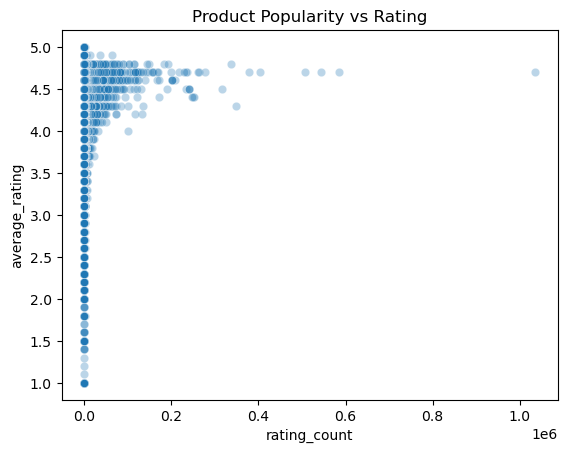

In [39]:
#2) how many ratings vs average rating 
sns.scatterplot(
    x='rating_count',
    y='average_rating',
    data=df_prod,
    alpha=0.3
)
plt.title("Product Popularity vs Rating")


In [40]:
#3) do reviews with the most helpful votes rate products good or bad?
vote_rating = df_merged.groupby('helpful_vote')['average_rating'].mean()

vote_rating

helpful_vote
0       4.372923
1       4.293028
2       4.251364
3       4.239345
4       4.238348
          ...   
4229         NaN
5979    4.500000
6142         NaN
6386    4.500000
8722         NaN
Name: average_rating, Length: 430, dtype: float64

/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_58720/1529127763.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['vote_bin'] = pd.cut(
/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_58720/1529127763.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby('vote_bin')['rating'].mean().plot(kind='bar')


<Axes: xlabel='vote_bin'>

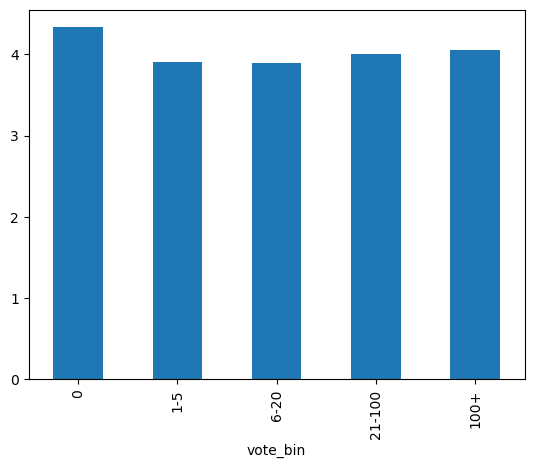

In [41]:
    #use pd.cut here -> converts numeric variable into bins (categorical)
    #specify bins -> (-1 to 0], (0 to 5], etc... 
df_merged['vote_bin'] = pd.cut(
    df_merged['helpful_vote'],
    bins=[-1,0,5,20,100,np.inf],
    labels=['0','1-5','6-20','21-100','100+']
)

df_merged.groupby('vote_bin')['rating'].mean().plot(kind='bar')

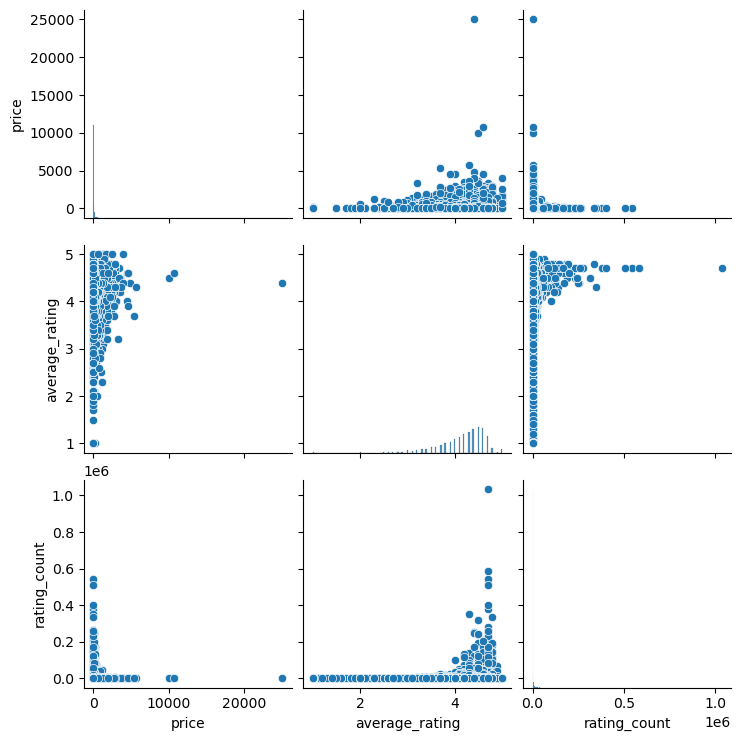

In [42]:
#4) pairplot of PRODUCT data price, average_rating, rating_count
sns.pairplot(
    df_prod[['price','average_rating','rating_count']]
)

<Axes: >

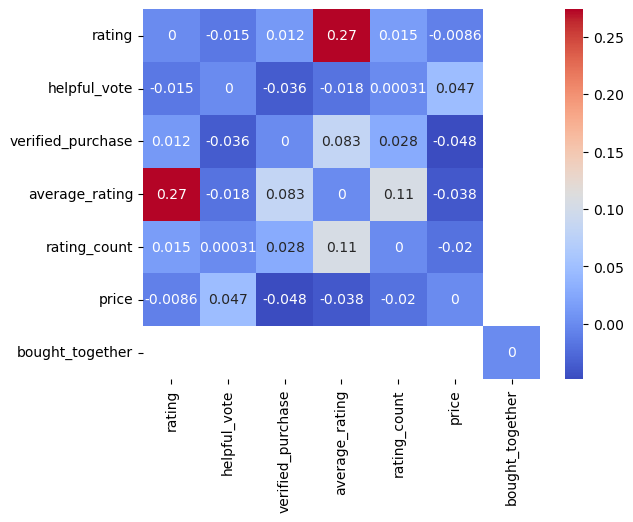

In [43]:
#5) HEATMAP for product dataset 
corr = df_prod.corr(numeric_only=True)
np.fill_diagonal(corr.values, 0)

sns.heatmap(corr, cmap='coolwarm', annot=True)

In [44]:
#5.5) for each rating number 1-5, how many were verified purchases or not 
display(pd.crosstab(
    df_merged['rating'],
    df_merged['verified_purchase']
))


verified_purchase,False,True
rating,,
1,5194,37594
2,2933,20513
3,4533,31187
4,11224,59823
5,31271,294738


In [45]:
#6) which category received highest ratings
df_prod.groupby('main_category')['average_rating'].mean().head(10)

main_category
AMAZON FASHION           4.276313
All Beauty               4.140816
All Electronics          4.170215
Amazon Devices           4.232075
Amazon Fire TV           4.354839
Amazon Home              4.285632
Apple Products           4.588152
Appliances               4.291667
Arts, Crafts & Sewing    4.382812
Audible Audiobooks       4.300000
Name: average_rating, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Cell Phones & Accessories'),
  Text(1, 0, 'All Electronics'),
  Text(2, 0, 'Home Audio & Theater'),
  Text(3, 0, 'Camera & Photo'),
  Text(4, 0, 'Computers'),
  Text(5, 0, 'Industrial & Scientific'),
  Text(6, 0, 'Tools & Home Improvement'),
  Text(7, 0, 'Office Products')])

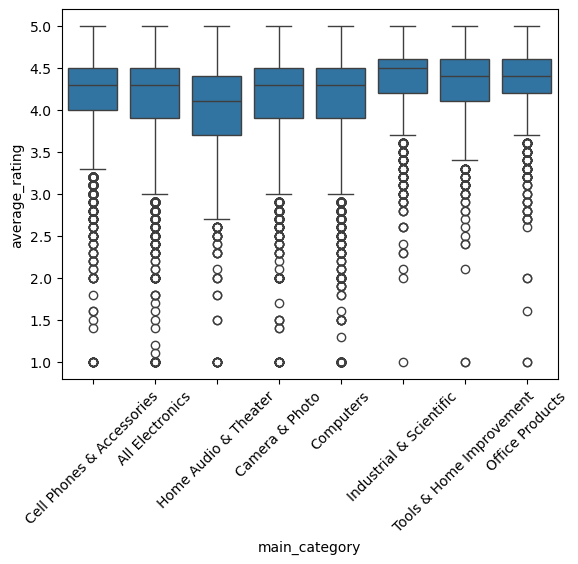

In [46]:
# 6) box plot ratings for most common categories 
top_categories = df_prod['main_category'].value_counts().sort_values(ascending=False).head(8).index
sns.boxplot(
    x='main_category',
    y='average_rating',
    data=df_prod[df_prod['main_category'].isin(top_categories)]
)

plt.xticks(rotation=45)

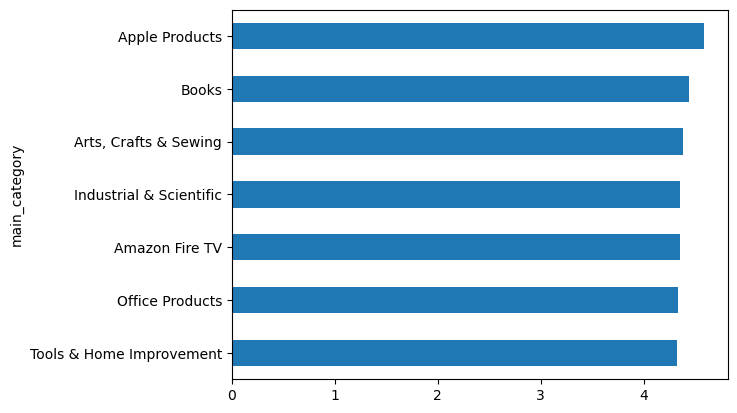

In [47]:
#6B) bar-h graph which category received highest ratings
cat_rating = (
    df_prod.groupby('main_category')
    .agg({'average_rating':'mean','rating_count':'sum'})
    .query('rating_count > 1000')
    .sort_values('average_rating', ascending=False)
    .head(7)
)

cat_rating['average_rating'].plot(kind='barh')
plt.gca().invert_yaxis()

/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_58720/2751332949.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['review_year']=df_merged['timestamp'].dt.year


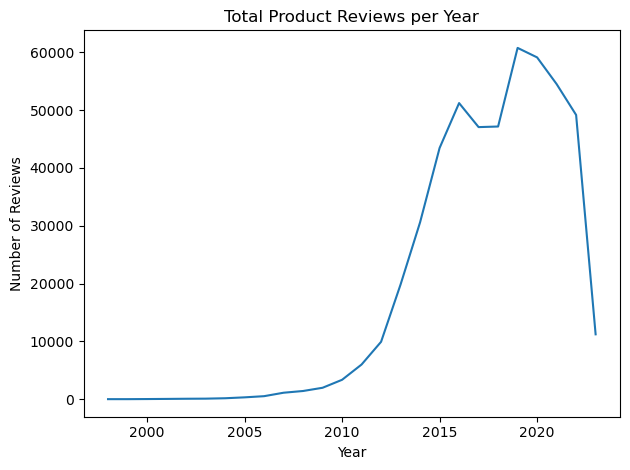

In [48]:
#7) LINE PLOT reviews over time 
df_merged['review_year']=df_merged['timestamp'].dt.year

df_merged.groupby('review_year').size().plot(kind='line')     #for each review_year, how many rows aka reviews there are
plt.title('Total Product Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.tight_layout()

/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_58720/712641627.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['review_year'] = df_merged['timestamp'].dt.year


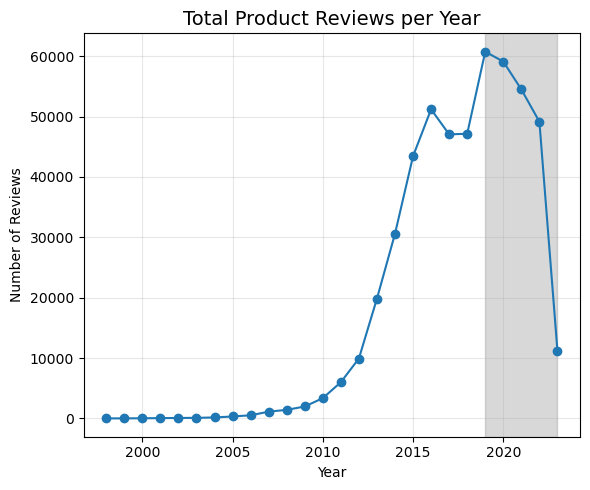

In [49]:
#USE THIS GRAPH


df_merged['review_year'] = df_merged['timestamp'].dt.year

reviews_per_year = df_merged.groupby('review_year').size()

plt.figure(figsize=(6,5))

plt.plot(reviews_per_year.index, reviews_per_year.values, marker='o')

plt.title("Total Product Reviews per Year", fontsize=14)
plt.axvspan(2019, 2023, color='grey', alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: xlabel='review_year'>

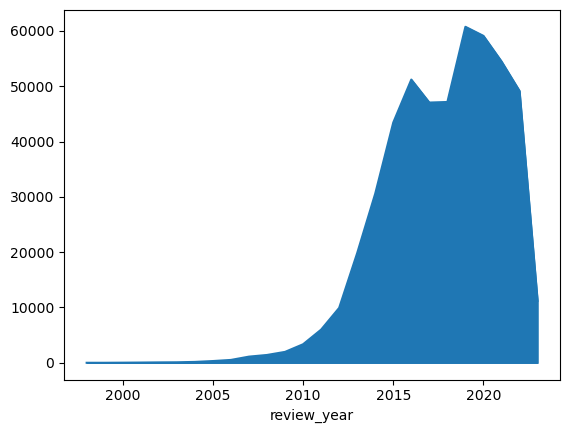

In [50]:
#area plot of number of reviews by year
df_merged.groupby('review_year').size().plot(kind='area')

In [51]:

#Plots - scatter matrix, line, waterfall, area, pair
#Box plot of outcomes by category 
#Correlation matrix, heatmap!
#Crosstab table or grouped means





# 4) Conclusions: Expected or Unexpected
- explained in essay



# 5) Conclusions: Datasets Disqualified  
- explained in essay


# 6) Conclusions: Supervised or Unsupervised analysis   
- explained in essay


<br><br>
---
# 📊 Milestone 4 START Multivariate Analysis, Modeling, Etc.



---


In [52]:
# Clean up df_prod 

# Delete all unknown products with NaN average_rating
df_prod = df_prod.dropna(subset=['average_rating'])
df_prod.info()


<class 'pandas.core.frame.DataFrame'>
Index: 74907 entries, 4 to 499997
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             74907 non-null  int64         
 1   review_title       74907 non-null  object        
 2   text               74907 non-null  object        
 3   images             74907 non-null  object        
 4   asin               74907 non-null  object        
 5   parent_asin        74907 non-null  object        
 6   user_id            74907 non-null  object        
 7   timestamp          74907 non-null  datetime64[ns]
 8   helpful_vote       74907 non-null  int64         
 9   verified_purchase  74907 non-null  bool          
 10  main_category      74306 non-null  object        
 11  product_title      74907 non-null  object        
 12  average_rating     74907 non-null  float64       
 13  rating_count       74907 non-null  float64       
 14  price     

Text(0.5, 1.0, 'Heatmap of Numeric Features Correlations')

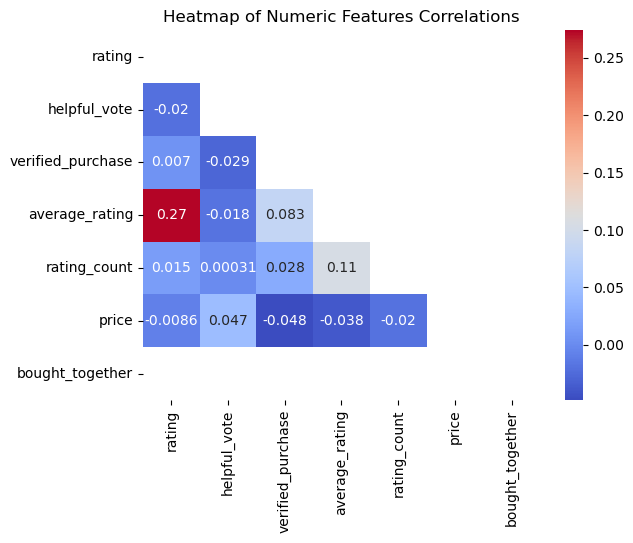

In [53]:
#1) Multivariate Analysis
#heatmap, bubble, PCA, pairplot, etc.
#Notes -> df_prod = one row per product (parent_asin) vs. df_merged (every review for product)
# df_prod[['product_title','average_rating']]

#Heatmap
corr = df_prod.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  #get rid of upper tri 
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True)
plt.title('Heatmap of Numeric Features Correlations')

/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_58720/240857840.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['log_rating_count'] = np.log1p(df_plot['rating_count'])


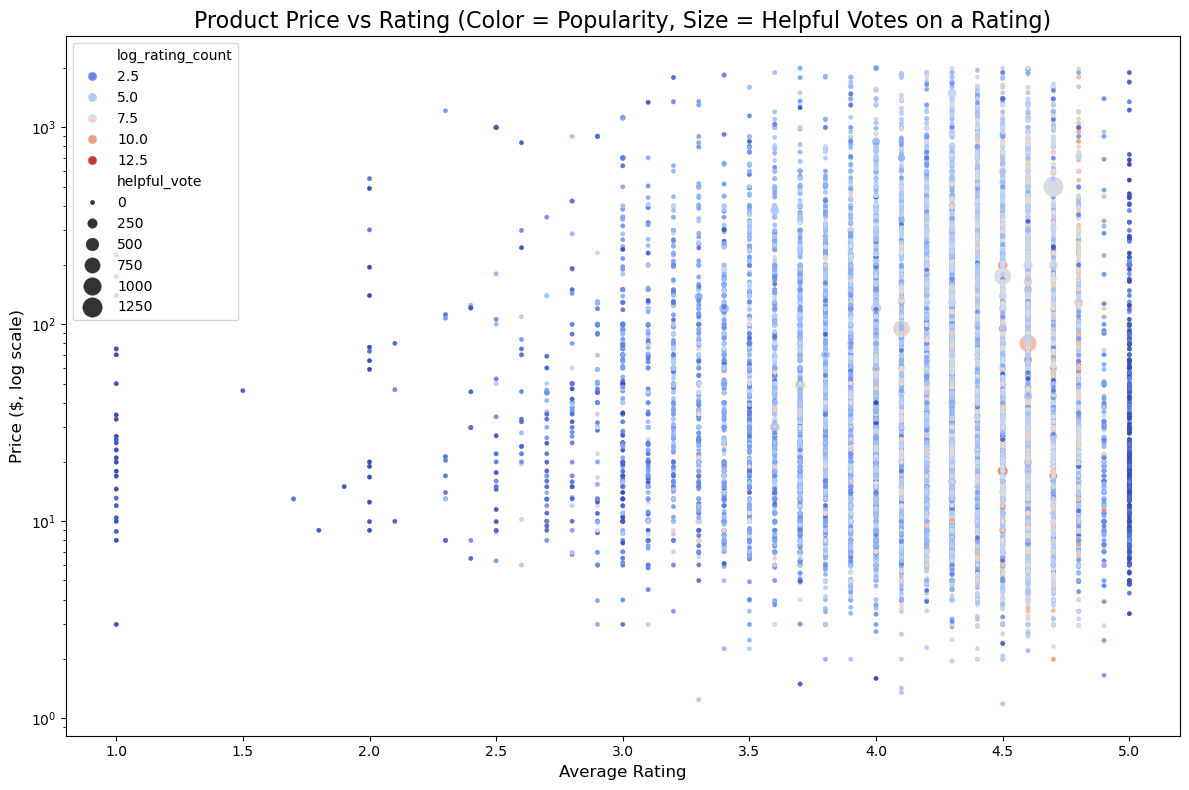

In [54]:
#Bubble Plot 

#remove extreme outliers 
df_plot = df_prod[(df_prod['price'] > 1) & (df_prod['price'] < 2000)]
df_plot['log_rating_count'] = np.log1p(df_plot['rating_count'])

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x="average_rating",
    y="price",
    size="helpful_vote",
    hue="log_rating_count",
    sizes=(10, 200),        # smaller bubbles
    alpha=1.0,              # transparency to reduce clutter
    palette="coolwarm",
    edgecolor=None
)

plt.yscale('log')

plt.title("Product Price vs Rating (Color = Popularity, Size = Helpful Votes on a Rating)", fontsize=16)
plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Price ($, log scale)", fontsize=12)
plt.tight_layout()

plt.show()

0    0.282494
1    0.258211
2    0.237415
3    0.221879
dtype: float64


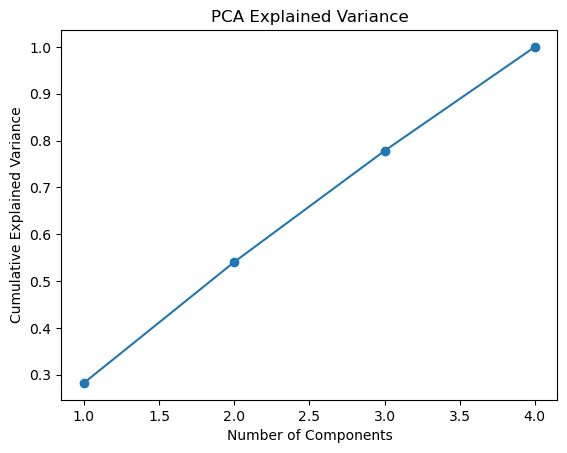

In [55]:
#PCA 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# select numeric features
features = ['price', 'average_rating', 'rating_count', 'helpful_vote']
df_pca = df_prod[features].dropna().copy()

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# fit PCA to X_scaled
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# explained variance
import pandas as pd
explained = pd.Series(pca.explained_variance_ratio_)

print(explained)

#Plot explained variance cumsum
plt.plot(range(1, len(explained)+1), explained.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [56]:
pca_features = ['price', 'average_rating', 'rating_count', 'helpful_vote']

df_pca = df_prod[pca_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

components_df = pd.DataFrame(
    pca.components_,
    columns=pca_features,
    index=[f'PC{i}' for i in range(1, pca.components_.shape[0] + 1)]
)

print(components_df.round(3))

     price  average_rating  rating_count  helpful_vote
PC1 -0.369           0.660         0.616        -0.220
PC2  0.562           0.206         0.369         0.711
PC3  0.736           0.093         0.104        -0.663
PC4  0.082           0.716        -0.688         0.084


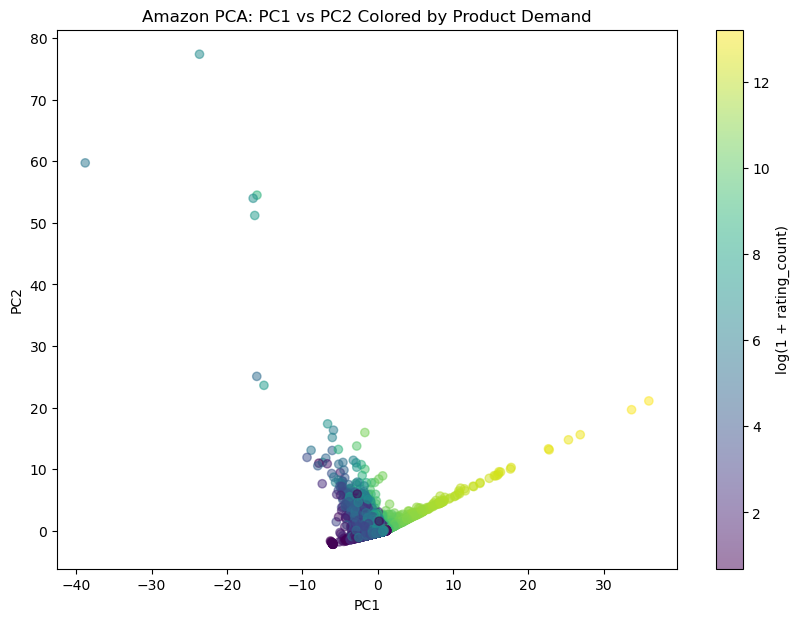

In [57]:
#PCA plot PC1 VS PC2

# scores dataframe
df_scores = pd.DataFrame(
    X_pca[:, :2],   #only first 2 PC's
    columns=['PC1', 'PC2']
)

# attach target
df_scores['rating_count'] = df_pca['rating_count'].values

# log transform for coloring
df_scores['log_rating_count'] = np.log1p(df_scores['rating_count'])

# plot
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df_scores['PC1'],
    df_scores['PC2'],
    c=df_scores['log_rating_count'],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Amazon PCA: PC1 vs PC2 Colored by Product Demand")

cbar = plt.colorbar(scatter)
cbar.set_label("log(1 + rating_count)")

plt.show()

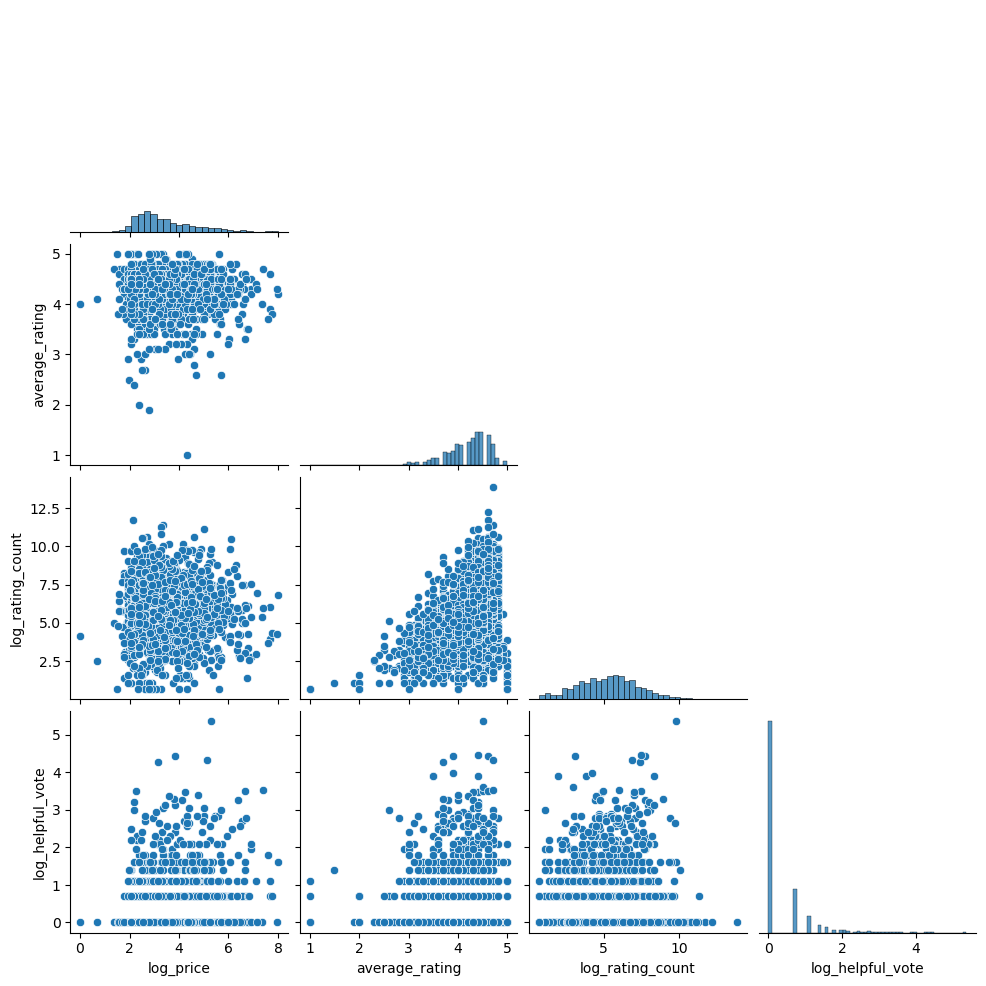

In [58]:
#Pairplot
df_pair = df_prod.copy()

df_pair['log_price'] = np.log1p(df_pair['price'])
df_pair['log_rating_count'] = np.log1p(df_pair['rating_count'])
df_pair['log_helpful_vote'] = np.log1p(df_pair['helpful_vote'])

features = ['log_price', 'average_rating', 'log_rating_count', 'log_helpful_vote']

sns.pairplot(df_pair[features].sample(3000), corner=True)
plt.show()

### Modeling Section Start

In [59]:
#2) Modeling (create df_model)
features = ['price', 'average_rating', 'helpful_vote']
target = 'rating_count'

df_model = df_prod[features + [target]].dropna().copy()

# log transform useful skewed predictors
df_model['log_price'] = np.log1p(df_model['price'])
df_model['log_helpful_vote'] = np.log1p(df_model['helpful_vote'])

# optional: also log-transform target, but then use that as y
df_model['log_rating_count'] = np.log1p(df_model['rating_count'])

# predictors
X = df_model[['log_price', 'average_rating', 'log_helpful_vote']]

# choose ONE target version
y = df_model['log_rating_count']   # recommended
# y = df_model['rating_count']     # alternative

#train,test,split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

#2a) Linear Regression with pipeline of scaling
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

lin_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# CV RMSE
cv_scores = cross_val_score(
    lin_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Linear Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Linear Regression Test RMSE:", rmse)
print("Linear Regression Test R2:", r2)

Linear Regression CV RMSE: 1.7425457948362104
Linear Regression Test RMSE: 1.7598691511328184
Linear Regression Test R2: 0.11403015844760511


In [60]:
#2b) Random Forest w/ CV, hyperparameter tuning, metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=0)

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

#create RS-CV 
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=0,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Params:", rf_search.best_params_)

Best Params: {'n_estimators': 50, 'min_samples_split': 10, 'max_depth': 10}


In [61]:
#use best rf
best_rf = rf_search.best_estimator_

#Test performance of rf model
y_pred_rf = best_rf.predict(X_test)

#rmse
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Test RMSE:", rmse_rf)

Random Forest Test RMSE: 1.6431838362976672


In [62]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)

average_rating      0.841266
log_price           0.123649
log_helpful_vote    0.035086
dtype: float64


In [63]:
comparisondf = pd.DataFrame({
"Linear RMSE":[rmse],
"Random Forest RMSE:":[rmse_rf]
},index=['RMSE'])
comparisondf

,Linear RMSE,Random Forest RMSE:
RMSE,1.759869,1.643184


## Additional Analysis using ratings and demand 

### 4DF) df_amz (product family, avg rating, rating_count, help_vote, price)

In [64]:
#create df_amz GROUPED BY unique product family (parent_asin)
df_amz=df_merged.groupby('parent_asin').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count'),
    helpful_votes=('helpful_vote', 'sum'),
    price=('price', 'median')
).reset_index()

df_amz_raw = df_amz.copy()

df_amz.dropna(inplace=True)
df_amz


,parent_asin,avg_rating,rating_count,helpful_votes,price
0,0060897082,5.000000,1,2,8.05
4,0224073087,5.000000,1,0,6.20
5,0345803507,4.160000,25,2,11.13
6,0375505458,2.000000,1,2,8.95
7,0511189877,5.000000,1,1,8.95
...,...,...,...,...,...
177195,B0CBBSTGSN,4.500000,6,19,20.59
177217,B0CBDFVNJ5,5.000000,1,0,259.95
177262,B0CBMM3DS6,5.000000,1,8,16.99
177289,B0CBS2BKLF,5.000000,1,0,24.99


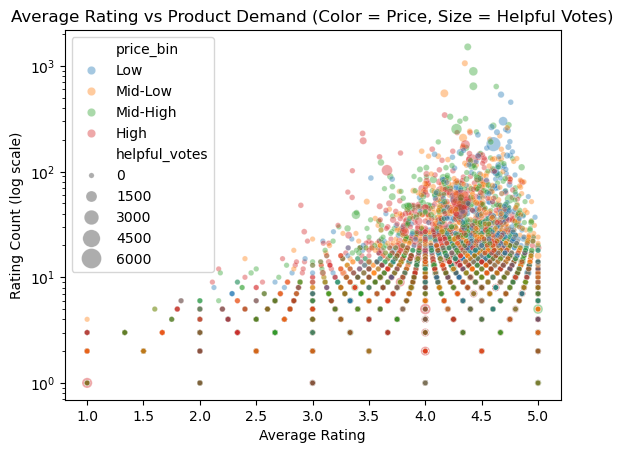

In [65]:
#bubble plot avg rating vs. demand (sized by helpful votes)
#create bins for price so can color
df_amz['price_bin'] = pd.qcut(df_amz['price'], q=4, labels=[
    'Low','Mid-Low','Mid-High','High'
])

#plot 
sns.scatterplot(
    data=df_amz,
    x='avg_rating',
    y='rating_count',
    size='helpful_votes',
    hue='price_bin',
    sizes=(15,220),
    alpha=0.4
)
plt.yscale('log')
plt.title("Average Rating vs Product Demand (Color = Price, Size = Helpful Votes)")
plt.xlabel("Average Rating")
plt.ylabel("Rating Count (log scale)")
plt.show()


In [66]:
#modeling section above changed to reflect average rating to predict demand (rating_count)

In [67]:
# fit model first
lin_model.fit(X_train, y_train)

# pull linear regression step
lr = lin_model.named_steps['linearregression']

# make coefficient table
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

print(coef_df)

            Feature  Coefficient
0         log_price    -0.026285
1    average_rating     0.652300
2  log_helpful_vote     0.040686


<br><br>
---
# 📊 Mod C1 CAPSTONE Milestone 1 START -> More Modeling
### df_prod = one product per row ('parent_asin') no duplicates
- NOTE helpful_vote is NOT sum of all reviews, just count the one review used for 'parent_asin' less ideal

### df_model = df_prod but all drop na, using x and y
- x = df_model features (log_price, average_rating, log_helpful_vote)
- y = df_model['log_rating_count']

---

In [150]:
X = df_model[ ['log_price', 'average_rating', 'log_helpful_vote']]
y = df_model['log_rating_count']

print("df_model:", df_model.shape) #dropped N/A's
print("X:", X.shape)

df_model: (39800, 8)
X: (39800, 3)


## Week 1 - Linear Regression 
"What product characteristics most associated with product popularity (rating_count)"


In [112]:
#Categorical and Continuous Features
display(df_merged.head(3))
display (df_model)

,rating,review_title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,main_category,product_title,average_rating,rating_count,price,categories,bought_together,vote_bin,review_year
0,3,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,NaN,Unknown Product,NaN,NaN,NaN,NaN,NaN,0,2022
1,1,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,NaN,Unknown Product,NaN,NaN,NaN,NaN,NaN,0,2020
2,5,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,NaN,Unknown Product,NaN,NaN,NaN,NaN,NaN,0,2018


,price,average_rating,helpful_vote,rating_count,log_price,log_helpful_vote,log_rating_count,popular_product,log_price_sq
4,45.99,4.0,0,423.0,3.849935,0.000000,6.049733,1,14.821998
7,19.99,4.3,9,16471.0,3.044046,2.302585,9.709417,1,9.266217
14,12.99,4.7,0,35.0,2.638343,0.000000,3.583519,0,6.960853
16,49.99,4.3,0,2785.0,3.931630,0.000000,7.932362,1,15.457711
17,24.95,4.6,0,1538.0,3.256172,0.000000,7.338888,1,10.602654
...,...,...,...,...,...,...,...,...,...
499857,8.99,4.2,0,64.0,2.301585,0.000000,4.174387,0,5.297292
499908,13.99,4.2,0,288.0,2.707383,0.000000,5.666427,0,7.329924
499952,17.90,4.6,0,87.0,2.939162,0.000000,4.477337,0,8.638673
499978,649.00,5.0,0,1.0,6.476972,0.000000,0.693147,0,41.951171


In [113]:
#Polynomial Terms -> "does price have non-linear relationship w/ popularity"
df_model['log_price_sq'] = df_model['log_price']**2    #test out squared price polynomial term

#lin reg to check both log_price and SQUARED log_price
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

def fit_lr(features):   #function to apply to both linear and non-linear models
    X = df_model[features]
    y = df_model['log_rating_count']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }


#two models here 
linear_results = fit_lr(['log_price', 'average_rating', 'log_helpful_vote'])
poly_results = fit_lr(['log_price', 'log_price_sq', 'average_rating', 'log_helpful_vote'])

#results 
pd.DataFrame({
    "Linear": linear_results,
    "Polynomial": poly_results
})
#ANSWER --> very minimal R-squared improvement from polynomial term

,Linear,Polynomial
RMSE,1.759869,1.755159
R2,0.114030,0.118766


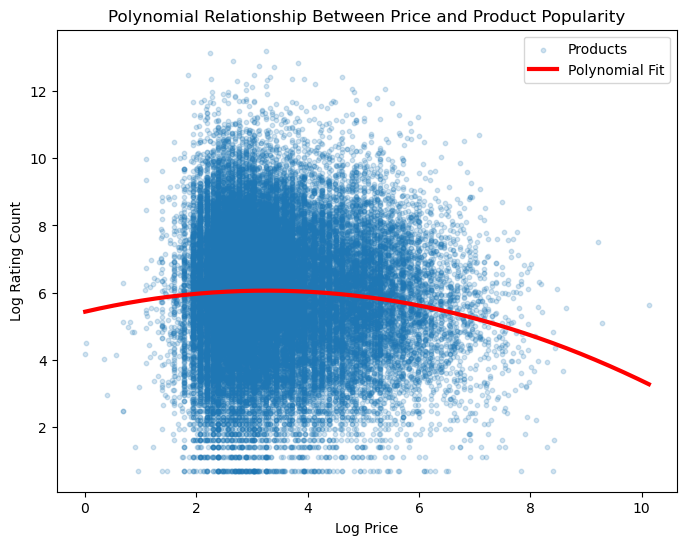

In [114]:
#graph of polynomial model curve (not very useful)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Fit polynomial model
X_poly = df_model[['log_price', 'log_price_sq']]
y = df_model['log_rating_count']

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Smooth x values
x = np.linspace(
    df_model['log_price'].min(),
    df_model['log_price'].max(),
    200
)

# Predict curve
y_curve = poly_model.predict(
    pd.DataFrame({
        'log_price': x,
        'log_price_sq': x**2
    })
)

# Scatter + curve
plt.figure(figsize=(8,6))

plt.scatter(
    df_model['log_price'],
    df_model['log_rating_count'],
    alpha=0.2,
    s=10,
    label='Products'
)

plt.plot(
    x,
    y_curve,
    color='red',
    linewidth=3,
    label='Polynomial Fit'
)

plt.xlabel("Log Price")
plt.ylabel("Log Rating Count")
plt.title("Polynomial Relationship Between Price and Product Popularity")
plt.legend()
plt.show()

In [115]:
# Interaction Terms -> "does average_rating matter more for products with many helpful votes"
from sklearn.linear_model import LinearRegression

y = df_model['log_rating_count']
#train/test/split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
#create new interaction model
interaction_model = LinearRegression()
interaction_model.fit(X_train, y_train)
#results 
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": interaction_model.coef_
})
#ANSWER --> negative -.034 interaction coef = effect of average_rating on popularity gets slightly WEAKER 
                                              #as helpful votes increase 

,Feature,Coefficient
0,log_price,-0.023425
1,average_rating,1.756671
2,log_helpful_vote,0.059747


In [117]:
#r-squared for interaction model 
r2_score(y_test, interaction_model.predict(X_test))

#note = 0.113 worse than linear model, so did not help fit the data better

0.11403015844760511

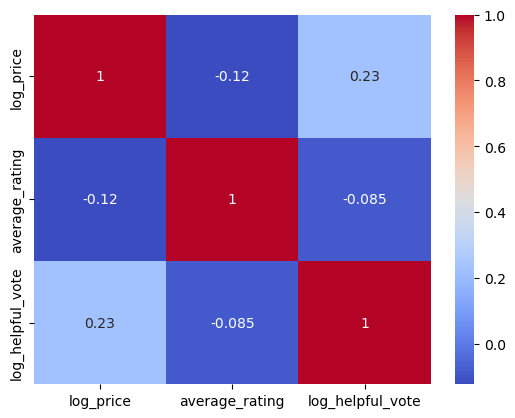

In [118]:
# Multicollinearity 
corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

#ANSWER -> corr > 0.8 probably MULTICOLLINEARITY 

In [119]:
#Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

#create VIF model design matrix
df_model['rating_helpful_interaction'] = (
    df_model['average_rating']*df_model['log_helpful_vote']
)

X_vif = df_model[
    ['log_price',
     'average_rating',
     'log_helpful_vote',
     'rating_helpful_interaction']
]

#Calculate VIF for all variables
vif_df = pd.DataFrame()

vif_df['Feature'] = X_vif.columns   #creates column with list of columns

vif_df['VIF']= [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]
vif_df
#ANSWER --> price and rating somewhat concern, serious multicollinear for helpful vote and interaction term

,Feature,VIF
0,log_price,10.006483
1,average_rating,9.462719
2,log_helpful_vote,126.833303
3,rating_helpful_interaction,126.158764


In [120]:
#)Linear Regression
features = ['price', 'average_rating', 'helpful_vote']
target = 'rating_count'

df_model = df_prod[features + [target]].dropna().copy()

# log transform useful skewed predictors
df_model['log_price'] = np.log1p(df_model['price'])
df_model['log_helpful_vote'] = np.log1p(df_model['helpful_vote'])

# optional: also log-transform target, but then use that as y
df_model['log_rating_count'] = np.log1p(df_model['rating_count'])

# predictors
X = df_model[['log_price', 'average_rating', 'log_helpful_vote']]

# choose ONE target version
y = df_model['log_rating_count']   # recommended
# y = df_model['rating_count']     # alternative

#train,test,split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

#2a) Linear Regression with pipeline of scaling
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
scaler = StandardScaler()


lin_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# CV RMSE
cv_scores = cross_val_score(
    lin_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Linear Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Linear Regression Test RMSE:", rmse)
print("Linear Regression Test R2:", r2)

Linear Regression CV RMSE: 1.7425457948362104
Linear Regression Test RMSE: 1.7598691511328184
Linear Regression Test R2: 0.11403015844760511


## Week 2 - Lasso, Ridge, Elastic Net


In [121]:
#1) LASSO MODEL - start

#SETUP
    # predictors
X = df_model[['log_price', 'average_rating', 'log_helpful_vote']]

    # target 
y = df_model['log_rating_count'] 

#train,test,split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

#MODEL -> Lasso Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=0, max_iter=10000)
)

# CV RMSE
cv_scores = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Lasso Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
lasso_model.fit(X_train, y_train)

#FIND BEST ALPHA value -> using .named_steps
bestalpha = lasso_model.named_steps['lassocv'].alpha_
print('best alpha:', bestalpha)
#Predict using X_test
y_pred = lasso_model.predict(X_test)

#Metrics
l_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
l_r2 = r2_score(y_test, y_pred)
print("Lasso Regression Test RMSE:", l_rmse)
print("Lasso Regression Test R2:", l_r2)


Lasso Regression CV RMSE: 1.7425464139225135
best alpha: 0.0006519379605576884
Lasso Regression Test RMSE: 1.7598663101415728
Lasso Regression Test R2: 0.11403301892223805


In [122]:
#FIND coefficient values after lasso adjustments
info = lasso_model.named_steps['lassocv']

coef_table = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient': info.coef_
})

coef_table  #note log_price almost 0.0 

,Feature,Coefficient
0,log_price,-0.025508
1,average_rating,0.651665
2,log_helpful_vote,0.039801


In [123]:
#2) RIDGE REGRESSION MODEL - start

#MODEL -> Ridge Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4,4,100),cv=5)
        #! FIND BEST ALPHA on log scale so 100 values between 10^-4 and 10^4 
)

# CV RMSE
cv_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Ridge Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
ridge_model.fit(X_train, y_train)

#FIND BEST ALPHA value -> using .named_steps
bestalpha = ridge_model.named_steps['ridgecv'].alpha_
print('best alpha:', bestalpha)
#Predict using X_test
y_pred = ridge_model.predict(X_test)

#Metrics
r_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_r2 = r2_score(y_test, y_pred)
print("Ridge Regression Test RMSE:", r_rmse)
print("Ridge Regression Test R2:", r_r2)


Ridge Regression CV RMSE: 1.7425458804656948
best alpha: 25.950242113997373
Ridge Regression Test RMSE: 1.7598626423368082
Ridge Regression Test R2: 0.11403671187380982


In [126]:
#3) ELASTIC NET REGRESSION MODEL - start

#MODEL -> elastic net Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

elastic_model = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=np.logspace(-4,4,100),
                 l1_ratio=[0.1,0.5,0.7,0.9,1.0],
                #! HERE FIND BEST RATIO (0.0 L2 ridge vs. 1.0 L1 lasso)
                 cv=5)
    
)

# CV RMSE
cv_scores = cross_val_score(
    elastic_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("ElasticNet Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
elastic_model.fit(X_train, y_train)

#FIND BEST L1 RATIO value -> using .named_steps
bestratio = elastic_model.named_steps['elasticnetcv'].l1_ratio_
print('best ratio:', bestratio)
            #note = best ratio = 0.1 (closer to R2 ridge)
#Predict using X_test
y_pred = elastic_model.predict(X_test)

#Metrics
e_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
e_r2 = r2_score(y_test, y_pred)
print("ElasticNet Regression Test RMSE:", e_rmse)
print("ElasticNet Regression Test R2:", e_r2)


ElasticNet Regression CV RMSE: 1.7425460068500152
best ratio: 0.1
ElasticNet Regression Test RMSE: 1.7598657330163576
ElasticNet Regression Test R2: 0.1140336000047869


### All 3 Model Metric Comparisons

In [127]:
comparisondf = pd.DataFrame({                   #USE THIS FIGURE maybe
"Lasso":[l_rmse, l_r2],         
"Ridge":[r_rmse, r_r2],
'ElasticNet': [e_rmse, e_r2]
},index=['RMSE', 'R2'])
comparisondf

,Lasso,Ridge,ElasticNet
RMSE,1.759866,1.759863,1.759866
R2,0.114033,0.114037,0.114034


## Week 3 - Fwd/Back Selection, PCR, PLSR


In [128]:
#3A1) Fwd Selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

sfs_for = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='forward',
    cv=5
)

sfs_for.fit(X, y)

selected_features = X.columns[sfs_for.get_support()]
print(selected_features)


Index(['average_rating'], dtype='object')


In [129]:
#3A2) Backward Selection
sfs_back = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='backward',
    cv=5
)
sfs_back.fit(X,y)
selected_features = X.columns[sfs_back.get_support()]
print(selected_features)

Index(['average_rating', 'log_helpful_vote'], dtype='object')


In [130]:
#3B) PCR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

#create pcr PIPELINE
pcr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('lr', LinearRegression())
])

pcr.fit(X_train, y_train)

y_pred = pcr.predict(X_test)

print("PCR R2:", r2_score(y_test, y_pred))

PCR R2: 0.11389725426465847


In [131]:
#Explained Variance Ratio for PC's
pca = PCA()
pca.fit(StandardScaler().fit_transform(X))

print(pca.explained_variance_ratio_)

[0.43321725 0.31039886 0.25638389]


In [132]:
#3C) PLSR
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred = pls.predict(X_test)

print(
    "PLSR R2:",
    r2_score(y_test, y_pred)
)

PLSR R2: 0.1140420991957185


## Week 4 - Logistic Regression, Feature Scaling (convert CLASSIFICATION here)


In [133]:
#4A) Logistic Regression (using above MEDIAN rating_count =1 , below = 0 )  so 50/50% split even
median_reviews = df_model['rating_count'].median() #417.0

#create NEW COLUMN for binary popular product
df_model['popular_product'] = (
    df_model['rating_count'] > median_reviews #boolean T/F here
).astype(int)      #CONVERT 1 or 0 here using .astype !
df_model

,price,average_rating,helpful_vote,rating_count,log_price,log_helpful_vote,log_rating_count,popular_product
4,45.99,4.0,0,423.0,3.849935,0.000000,6.049733,1
7,19.99,4.3,9,16471.0,3.044046,2.302585,9.709417,1
14,12.99,4.7,0,35.0,2.638343,0.000000,3.583519,0
16,49.99,4.3,0,2785.0,3.931630,0.000000,7.932362,1
17,24.95,4.6,0,1538.0,3.256172,0.000000,7.338888,1
...,...,...,...,...,...,...,...,...
499857,8.99,4.2,0,64.0,2.301585,0.000000,4.174387,0
499908,13.99,4.2,0,288.0,2.707383,0.000000,5.666427,0
499952,17.90,4.6,0,87.0,2.939162,0.000000,4.477337,0
499978,649.00,5.0,0,1.0,6.476972,0.000000,0.693147,0


In [361]:
#Create logistic model 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score


X = df_model[
    ['log_price', 'average_rating', 'log_helpful_vote']
]

y = df_model['popular_product']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

#
logist_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

logist_model.fit(X_train, y_train)

pred = logist_model.predict(X_test)

display(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

'Accuracy:'

0.6290201005025126

'AUC:'

0.6682318441755453

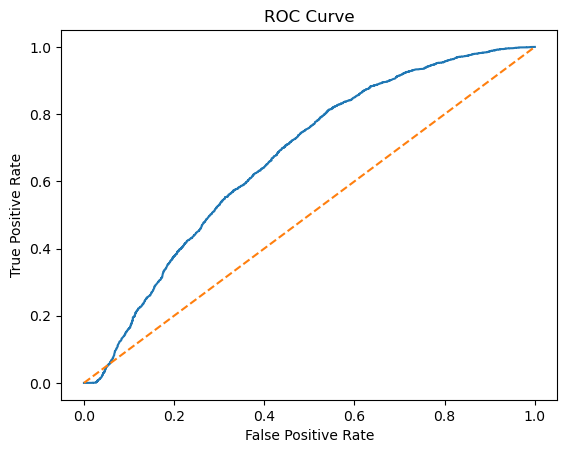

In [135]:
#GRAPH logistic model                           #USE FIGURE MAYBE
from sklearn.metrics import roc_curve, auc

probs = logist_model.predict_proba(X_test)[:,1] #list of all probabilities predicted from model ! 

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

#results
display(
    'AUC:', roc_auc_score(y_test, probs)
)

plt.show()

In [136]:
#4B) Feature Scaling

#Before scaling
example_scale = df_model[
    ['log_price', 'average_rating', 'log_helpful_vote']
].describe()
display(example_scale)


#After Scaling  (just use standardscaler)
X_scaled = scaler.fit_transform(example_scale)

#print scaled
now_scaled = pd.DataFrame(
    X_scaled,
    columns=['log_price','average_rating','log_helpful_vote']
).describe()
display(now_scaled)

#NOW MEAN = 0, and STDEV = 1 

,log_price,average_rating,log_helpful_vote
count,39800.000000,39800.000000,39800.000000
mean,3.440167,4.327626,0.357340
std,1.124182,0.371246,0.685439
min,0.009950,1.000000,0.000000
25%,2.632608,4.200000,0.000000
50%,3.173041,4.400000,0.000000
75%,4.074992,4.600000,0.693147
max,10.126551,5.000000,7.145196


,log_price,average_rating,log_helpful_vote
count,8.000000e+00,8.000000e+00,8.000000e+00
mean,-8.326673e-17,5.551115e-17,2.775558e-17
std,1.069045e+00,1.069045e+00,1.069045e+00
min,-3.782305e-01,-3.781957e-01,-3.780609e-01
25%,-3.780599e-01,-3.779655e-01,-3.780609e-01
50%,-3.779800e-01,-3.778923e-01,-3.780212e-01
75%,-3.778067e-01,-3.778668e-01,-3.778856e-01
max,2.645751e+00,2.645751e+00,2.645751e+00


## Week 5 - SVM, Kernel Trick, Regularization of Support Vector Machines


In [90]:
from sklearn.svm import SVC

# SVM with linear kernel
svm_linear = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=1, probability=True, random_state=0)
)

svm_linear.fit(X_train, y_train)

y_pred_svm = svm_linear.predict(X_test)
y_prob_svm = svm_linear.predict_proba(X_test)[:, 1]

print("===== Linear SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_svm))

===== Linear SVM =====
Accuracy : 0.6311557788944724
Precision: 0.5953953576146442
Recall   : 0.7993412718520395
F1 Score : 0.6824572788232749
ROC AUC  : 0.6684496251131126


In [91]:
# SVM with RBF kernel   (1min runtime)
svm_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=0)
)

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("===== RBF Kernel SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall   :", recall_score(y_test, y_pred_rbf))
print("F1 Score :", f1_score(y_test, y_pred_rbf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rbf))

===== RBF Kernel SVM =====
Accuracy : 0.6445979899497487
Precision: 0.6144553644553644
Recall   : 0.7603242969343805
F1 Score : 0.6796512286264296
ROC AUC  : 0.689858289921828


In [92]:
#Regularization SVM with random search and tuning C      (4 min runtime)
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svm_pipe = make_pipeline(
    StandardScaler(),
    SVC(random_state=0)
)

param_dist = {
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.1]
}

svm_search = RandomizedSearchCV(
    svm_pipe,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=0,
    n_jobs=1
)

svm_search.fit(X_train, y_train)

print("Best params:", svm_search.best_params_)

Best params: {'svc__kernel': 'rbf', 'svc__gamma': 0.1, 'svc__C': 10}


In [93]:
#now test model with best parameters (4 min runtime)
best_params = svm_search.best_params_

best_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel=best_params['svc__kernel'],
        C=best_params['svc__C'],
        gamma=best_params['svc__gamma'],
        probability=True,
        random_state=0
    )
)
#fit model
best_svm.fit(X_train, y_train)

#y_pred and y_prob
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

best_svm.fit(X_train, y_train)
print("===== Best SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_svm))

===== Best SVM =====
Accuracy : 0.6445979899497487
Precision: 0.6145022531749283
Recall   : 0.7600709399543958
F1 Score : 0.6795786612300374
ROC AUC  : 0.6927848376738104


## Week 6 - Decision Trees, Random Forests


In [420]:
#1) Decision Tree w/ randomized search and CV
dt = DecisionTreeClassifier(random_state=0)

#a) make params
param_dist = {
    'ccp_alpha': [0.0, 0.001, 0.01,  0.05, 0.1],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10,15],
    'min_samples_leaf': [1,2,5,10]
}

#b) make RS-CV
dt_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)
#c) fit RS-CV
dt_search.fit(X_train,y_train)

best_dt = dt_search.best_estimator_

#d) predict using RS-CV
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:,1]

#e) metrics
rmse_dt = np.sqrt(mean_squared_error(y_test,y_pred_dt))
r2_dt = r2_score(y_test,y_pred_dt)

print("===== Decision Tree =====")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))


===== Decision Tree =====
Accuracy : 0.6298994974874372
Precision: 0.5871513102282333
Recall   : 0.873271310032688
F1 Score : 0.7021835826930853
ROC AUC  : 0.6779624000442919


In [421]:
#2) random forest with randomized search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=0)

#make params
param_dist = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5,10]
}

#make RS-CV
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)
#fit RS-CV
rf_search.fit(X_train,y_train)

best_rf = rf_search.best_estimator_

#predict using RS-CV

#metrics
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

#e) metrics

print("===== Random Forest  =====")
print('best param:', best_rf)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))


===== Random Forest  =====
best param: RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=300,
                       random_state=0)
Accuracy : 0.6418341708542713
Precision: 0.6085196607555898
Recall   : 0.7938144329896907
F1 Score : 0.688925259138025
ROC AUC  : 0.6929722568085598


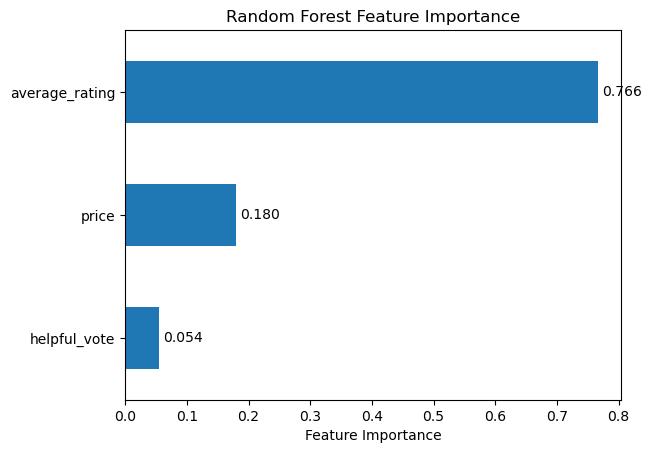

In [422]:
#feature importances graph         
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values()

ax = importance.plot(kind='barh')

# add labels to each bar
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=3
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

## ! Week 8 - K-Nearest Neighbors / Distance Metrics



- classification! y = "popular_product"
- REMEMBER used product_rating > median, so binary 0 or 1 should be about 50/50% split of data

X = df_model[['log_price', 'average_rating', 'log_helpful_vote']]


In [418]:
df_model

,price,average_rating,helpful_vote,rating_count,log_price,log_helpful_vote,log_rating_count,popular_product,Cluster,DBSCAN_Cluster
4,45.99,4.0,0,423.0,3.849935,0.000000,6.049733,1,0,0
7,19.99,4.3,9,16471.0,3.044046,2.302585,9.709417,1,1,1
14,12.99,4.7,0,35.0,2.638343,0.000000,3.583519,0,2,0
16,49.99,4.3,0,2785.0,3.931630,0.000000,7.932362,1,3,0
17,24.95,4.6,0,1538.0,3.256172,0.000000,7.338888,1,2,0
...,...,...,...,...,...,...,...,...,...,...
499857,8.99,4.2,0,64.0,2.301585,0.000000,4.174387,0,2,0
499908,13.99,4.2,0,288.0,2.707383,0.000000,5.666427,0,2,0
499952,17.90,4.6,0,87.0,2.939162,0.000000,4.477337,0,2,0
499978,649.00,5.0,0,1.0,6.476972,0.000000,0.693147,0,3,0


In [425]:
X = df_model[
    ['log_price',
     'average_rating',
     'log_helpful_vote']
]
y = df_model['popular_product']

#split train 80%, test set 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)


In [ ]:
# 1) KNN CLASSIFICATION

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

results = []    # list of results per distance metric

# compare 3 distance metrics
metrics = {
    "Manhattan": ("minkowski", 1),
    "Euclidean": ("minkowski", 2),
    "Minkowski (p=3)": ("minkowski", 3)
}

# loop through each distance metric
for name, (metric, p) in metrics.items():

    knn = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            metric=metric,
            p=p
        ))
    ])

    param_dist = {
        'knn__n_neighbors': [3, 5, 10, 15, 20, 30, 50],
        'knn__weights': ['uniform', 'distance']
    }

    # randomized search with cross-validation
    knn_search = RandomizedSearchCV(
        knn,
        param_distributions=param_dist,
        n_iter=5,
        cv=5,
        scoring='roc_auc',
        random_state=0,
        n_jobs=-1
    )

    # fit model
    knn_search.fit(X_train, y_train)

    # predictions
    y_pred = knn_search.best_estimator_.predict(X_test)
    y_prob = knn_search.best_estimator_.predict_proba(X_test)[:, 1]

    # save results
    results.append({
        'Distance': name,
        'Best K': knn_search.best_params_['knn__n_neighbors'],
        'Weights': knn_search.best_params_['knn__weights'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

knn_results = pd.DataFrame(results)
knn_results

,Distance,Best K,Weights,Accuracy,Precision,Recall,F1,ROC-AUC
0,Manhattan,20,uniform,0.621608,0.617083,0.639427,0.628056,0.668771
1,Euclidean,20,uniform,0.620603,0.616113,0.638421,0.627068,0.669027
2,Minkowski (p=3),20,uniform,0.619849,0.615329,0.637918,0.626420,0.668375


- analysis
- KNN here WORSE ROC-AUC than dt and rf (0.68,0.69)

In [427]:
# ==========================================
# 1B) Table of ROC-AUC and F1 vs. K

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# values of k to test
k_values = [3, 5, 10, 15, 20, 30, 50]

# distance metrics to compare
metrics = {
    "Manhattan": ("minkowski", 1),
    "Euclidean": ("minkowski", 2),
    "Minkowski (p=3)": ("minkowski", 3)
}

plot_results = []

# test every distance metric and k value
for distance_name, (metric, p) in metrics.items():
    
    for k in k_values:
        knn = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(
                n_neighbors=k,
                weights='uniform',
                metric=metric,
                p=p
            ))
        ])

        # fit model
        knn.fit(X_train, y_train)

        # predicted classes and probabilities
        y_pred = knn.predict(X_test)
        y_prob = knn.predict_proba(X_test)[:, 1]

        # save results
        plot_results.append({
            'Distance': distance_name,
            'K': k,
            'F1': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        })

knn_plot_results = pd.DataFrame(plot_results)

knn_plot_results.sort_values(by='ROC-AUC', ascending=False)

,Distance,K,F1,ROC-AUC
6,Manhattan,50,0.662976,0.685322
13,Euclidean,50,0.660615,0.683870
20,Minkowski (p=3),50,0.660853,0.683750
12,Euclidean,30,0.652705,0.679040
5,Manhattan,30,0.653047,0.678932
19,Minkowski (p=3),30,0.652486,0.678555
11,Euclidean,20,0.627068,0.669027
4,Manhattan,20,0.628056,0.668771
18,Minkowski (p=3),20,0.626420,0.668375
3,Manhattan,15,0.636037,0.662385


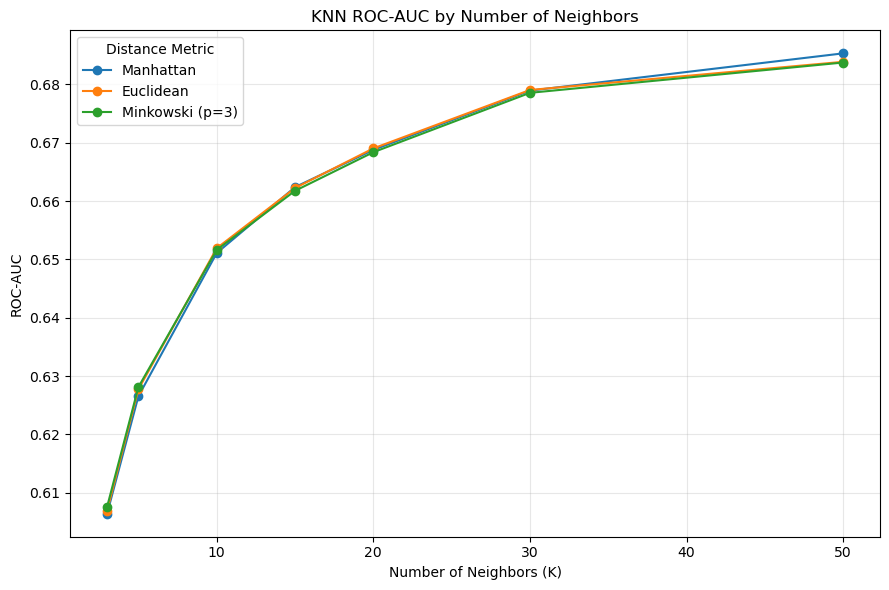

In [428]:
#ROC-AUC vs k Plot
plt.figure(figsize=(9, 6))

for distance_name in metrics.keys():

    metric_results = knn_plot_results[
        knn_plot_results['Distance'] == distance_name
    ]

    plt.plot(
        metric_results['K'],
        metric_results['ROC-AUC'],
        marker='o',
        label=distance_name
    )

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('ROC-AUC')
plt.title('KNN ROC-AUC by Number of Neighbors')
plt.legend(title='Distance Metric')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- analysis i think elbow would still be 10 here before diminishing gains

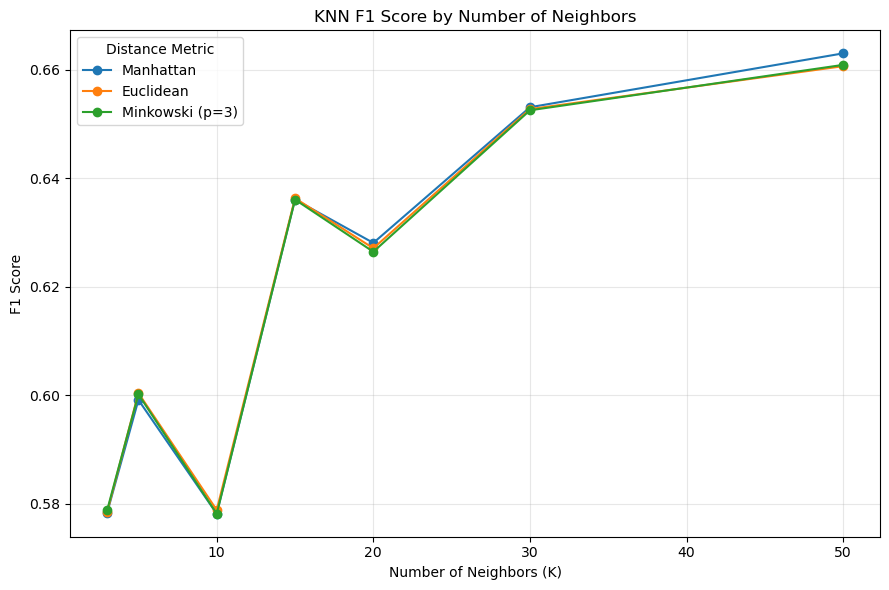

In [429]:
#F1 Score vs k Plot
plt.figure(figsize=(9, 6))

for distance_name in metrics.keys():

    metric_results = knn_plot_results[
        knn_plot_results['Distance'] == distance_name
    ]

    plt.plot(
        metric_results['K'],
        metric_results['F1'],
        marker='o',
        label=distance_name
    )

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.title('KNN F1 Score by Number of Neighbors')
plt.legend(title='Distance Metric')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [370]:
# PREVIOUS CODE, not using regression anymore 
# 
# #Plot RMSE vs k (euclidean distance)
# k_values = [3, 5, 10, 15, 20, 30, 50]
# rmse = []   #store rmse list

# #loop over all k values
# for k in k_values:

#     knn = Pipeline([
#         ('scaler', StandardScaler()),
#         ('knn', KNeighborsRegressor(
#             n_neighbors=k,
#             weights='uniform',
#             metric='minkowski',
#             p=2          # Euclidean
#         ))
#     ])

#     knn.fit(X_train, y_train)

#     y_pred = knn.predict(X_test)
#     #add rmse of each k to the list
#     rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# #plot 
# plt.figure(figsize=(6,4))
# # 2. Plot the entire line once (outside the loop)
# plt.plot(k_values, rmse, marker='o', color='tab:blue')

# # 3. Loop only to place the text labels
# for i, j in zip(k_values, rmse):
#     plt.text(i, j, f'({i}, {j:.2f})', ha='left', va='bottom', fontsize=9)

# # 4. Set up chart (outside the loop)
# plt.title('RMSE vs. Number of Neighbors')
# plt.xlabel('Number of Neighbors (k)')
# plt.ylabel('Test RMSE')
# plt.grid(alpha=0.3)

# # 5. Render the final plot
# plt.show()

In [371]:
# PREVIOUS CODE, not using regression anymore
# #Plot R2 vs k (euclidean)
# k_values = [3, 5, 10, 15, 20, 30, 50]
# r2_list = []   #store r2 list

# #loop over all k values
# for k in k_values:

#     knn = Pipeline([
#         ('scaler', StandardScaler()),
#         ('knn', KNeighborsRegressor(
#             n_neighbors=k,
#             weights='uniform',
#             metric='minkowski',
#             p=2          # Euclidean
#         ))
#     ])

#     knn.fit(X_train, y_train)

#     y_pred = knn.predict(X_test)
#     #add r2 of each k to the list
#     r2_list.append(r2_score(y_test, y_pred))

# #plot 
# plt.figure(figsize=(6,4))
# # 2. Plot the entire line once (outside the loop)
# plt.plot(k_values, r2_list, marker='o', color='tab:blue')

# # 3. Loop only to place the text labels
# for i, j in zip(k_values, r2_list):
#     plt.text(i, j, f'({i}, {j:.2f})', ha='left', va='top', fontsize=9)

# # 4. Set up chart (outside the loop)
# plt.title('R2 vs. Number of Neighbors')
# plt.xlabel('Number of Neighbors (k)')
# plt.ylabel('R2 Score')
# plt.grid(alpha=0.3)

# # 5. Render the final plot
# plt.show()

## Week 9 - Gradient Boost 
- include learning rate, number of estimators, tree depth, regularization


In [430]:
#1) Gradient boost classification 
X = df_model[
    ['log_price',
     'average_rating',
     'log_helpful_vote']
]
y = df_model['popular_product']

#split train 80%, test set 20%
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0, stratify=y
    )

gb = GradientBoostingClassifier(random_state=0)

#make params
param_dist = {
    'learning_rate': [0.01, 0.03, 0.1, 0.2, 0.5],
    'n_estimators':[100,200,400,600],
    'max_depth':[2,3,5,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf' : [1,2,5,10],
    'subsample' : [0.6, 0.8, 1.0],
    'max_features' : ['sqrt', 'log2', None]
}

#make RS-CV estimator
gb_search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)

#ITERATE FIND MODEL for each parameter setting using .fit
gb_search.fit(X_train, y_train)
#after done, auto fit one final best parameter model on x_train

#create variable for model with BEST Parameters
best_gb = gb_search.best_estimator_
print('best parameters', gb_search.best_params_)

#Predict using X_test
y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:,1]

#Metrics
gb_accuracy = accuracy_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)
gb_auc = roc_auc_score(y_test, y_prob)

print("GB Classification Test Accuracy:", gb_accuracy)
print("GB Classification Test Precision:", gb_precision)
print("GB Classification Test Recall:", gb_recall)
print("GB Classification Test F1:", gb_f1)
print("GB Classification Test ROC-AUC:", gb_auc)

best parameters {'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.03}
GB Classification Test Accuracy: 0.6417085427135678
GB Classification Test Precision: 0.6169195593431719
GB Classification Test Recall: 0.7462911742519487
GB Classification Test F1: 0.6754665452890305
GB Classification Test ROC-AUC: 0.6955365243193807


- only slightly better GB test ROC-AUC here 0.695

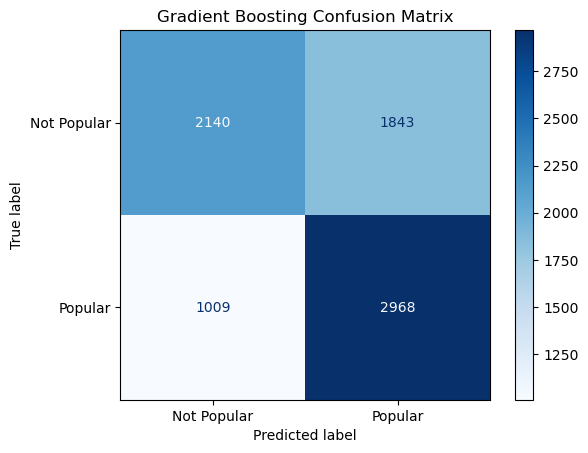

In [431]:
#1B) GB Confusion Matrix for test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Popular', 'Popular']
)

cm_display.plot(cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

- INTERPRET 
- a lot of FP (top R), 1843/4811 = 38.3% of all predicted positives
-  a lot of FN (bot L), 1009/3149 = 32.0% of all predicted neg
- recall (TP /TP+FN) = 2968/3977 = 0.746


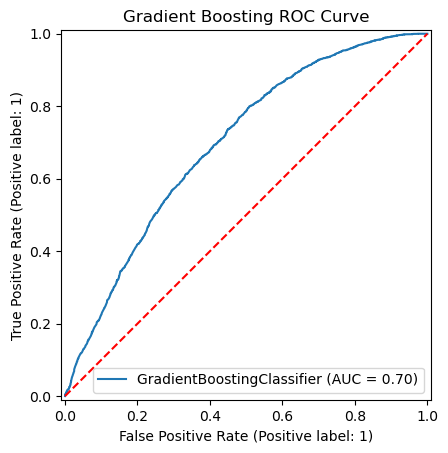

In [432]:
#1C) Plot ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_gb,
    X_test,
    y_test
)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("Gradient Boosting ROC Curve")
plt.show()

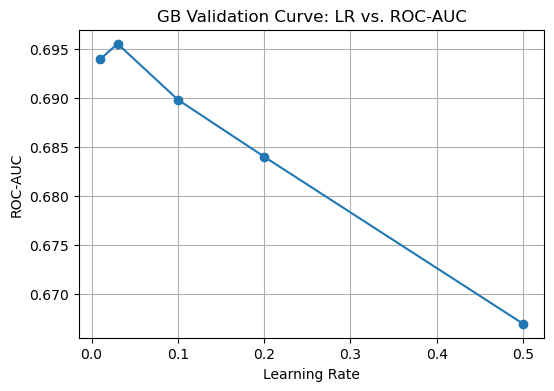

In [433]:
#1D) Validation curve: ROC-AUC vs Learning Rate

learning_rates = [0.01,0.03,0.1,0.2,0.5]
auc_scores = []

for lr in learning_rates:

    gb = GradientBoostingClassifier(
        learning_rate=lr,
        n_estimators=best_gb.n_estimators,
        max_depth=best_gb.max_depth,
        min_samples_split=best_gb.min_samples_split,
        min_samples_leaf=best_gb.min_samples_leaf,
        subsample=best_gb.subsample,
        max_features=best_gb.max_features,
        random_state=0
    )

    gb.fit(X_train, y_train)

    #Predict using X_test
    y_prob = gb.predict_proba(X_test)[:,1]

    #Save ROC-AUC
    auc_scores.append(
        roc_auc_score(y_test, y_prob)
    )

#Plot validation curve

plt.figure(figsize=(6,4))
plt.plot(learning_rates, auc_scores, marker='o')

plt.xlabel("Learning Rate")
plt.ylabel("ROC-AUC")
plt.title("GB Validation Curve: LR vs. ROC-AUC")

plt.grid(True)
plt.show()

-  actually here 0.03 best LR

chat report This figure will give you much more to discuss than the ROC curve alone. If it peaks around 0.1 (which is common), you can explain:

* Low learning rates (0.01–0.03): updates are too small, so the model underfits.
* Moderate learning rate (around 0.1): best balance between learning and generalization.
* High learning rates (0.2–0.5): updates become too aggressive, which can reduce performance due to overfitting or unstable learning.

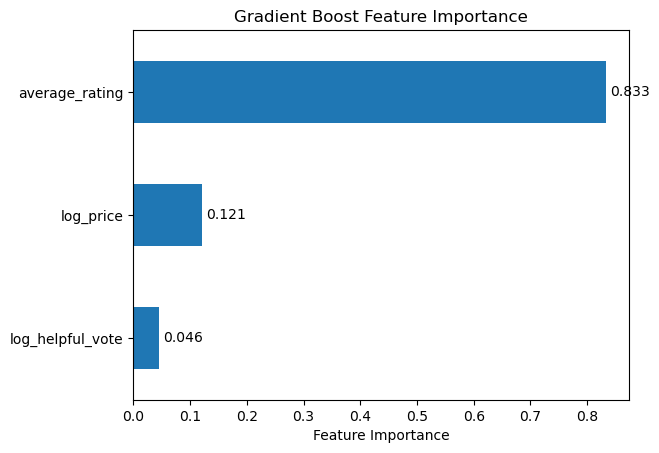

In [434]:
#1E) feature importances graph for GB        
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values()

ax = importance.plot(kind='barh')

# add labels to each bar
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=3
)

plt.xlabel("Feature Importance")
plt.title("Gradient Boost Feature Importance")
plt.show()

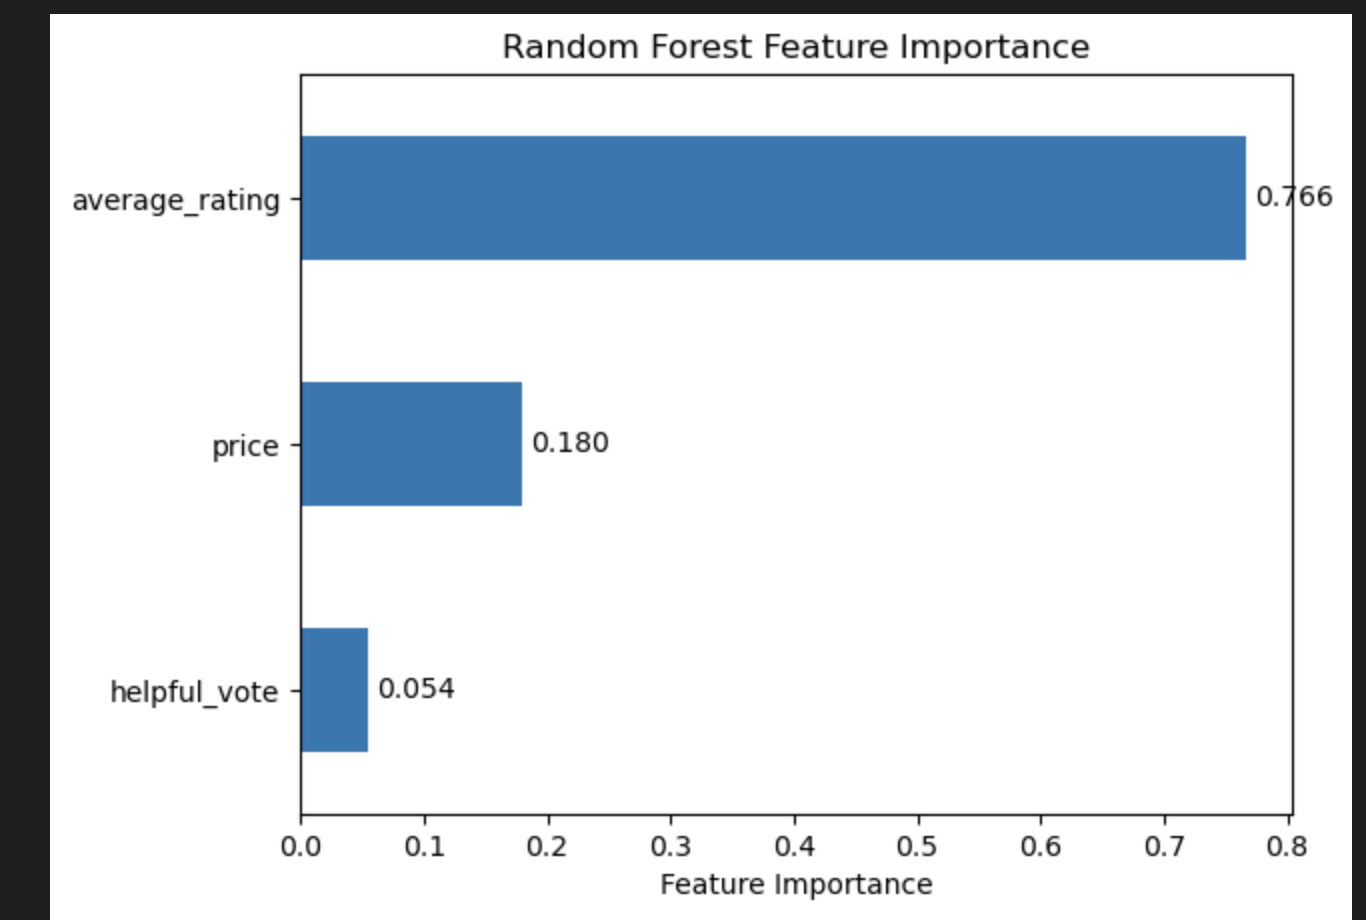

-> GB had MORE average_rating 0.833 vs. RF of 0.766
- ALSO LESS importance helpful vote (0.046 vs 0.054), less log_price 0.121 vs. RF of 0.180

Best number of trees: 306
Best validation ROC-AUC: 0.6992520699907978


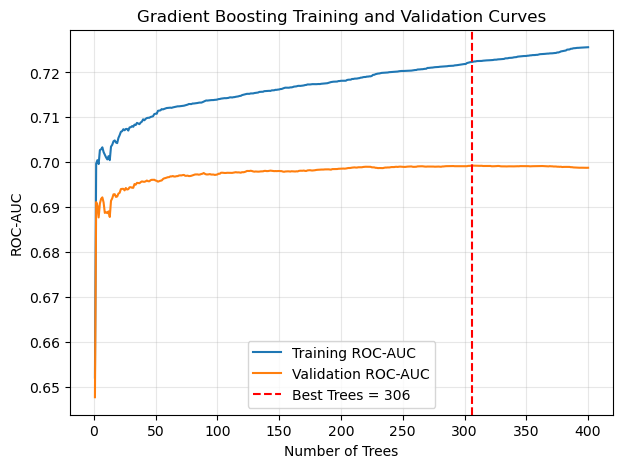

In [ ]:
#Training and Validation ROC-AUC vs Number of Trees

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

#split training data again into train and validation
X_gb_train, X_val, y_gb_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=0,
    stratify=y_train
)

#copy best gradient boosting model
gb_curve = clone(best_gb)

#fit only on new training set
gb_curve.fit(X_gb_train, y_gb_train)

#empty lists for train vs validation scores
train_auc = []
val_auc = []

#find predictions after each new tree
for train_prob, val_prob in zip(
    gb_curve.staged_predict_proba(X_gb_train),
    gb_curve.staged_predict_proba(X_val)
):
    #add score to list
    train_auc.append(
        roc_auc_score(y_gb_train, train_prob[:,1])
    )
    #add score to list
    val_auc.append(
        roc_auc_score(y_val, val_prob[:,1])
    )

#number of trees
trees = range(1, len(train_auc) + 1)

#find tree with highest validation ROC-AUC
best_tree = np.argmax(val_auc) + 1
best_val_auc = max(val_auc)

print("Best number of trees:", best_tree)
print("Best validation ROC-AUC:", best_val_auc)


#PART 2 

#plot training and validation curves
plt.figure(figsize=(7,5))
plt.plot(trees, train_auc, label='Training ROC-AUC')
plt.plot(trees,val_auc,label='Validation ROC-AUC')

plt.axvline(    #vertical line for tree number w/best score
    best_tree,
    color='red',
    linestyle='--',
    label=f'Best Trees = {best_tree}'
)

plt.xlabel("Number of Trees")
plt.ylabel("ROC-AUC")
plt.title("Gradient Boosting Training and Validation Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [391]:
# WRONG here, this is for the regression 
# #INTERPRET -
# - SURPRISING HERE residuals for evenly spaced cloud (homoscedastic) but here more FUNNEL-SHAPED (heteroscedastic) 
# - GB doesn't assume constant variance, still valid model
# - MEANING as predicted popular products increases, variance in prediction errors also increase (b/c harder to predict more popular if unavailable factors brand, product age, etc.)

## Week 10 - Clustering 1
- include k-means: elbow method, Silhouette score, feature scaling, distance metrics


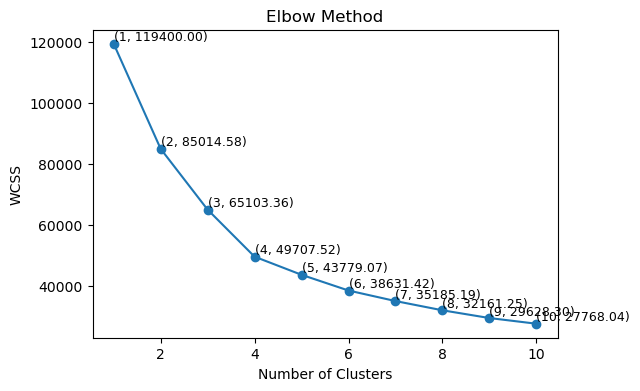

In [455]:
#1) Clustering 1 
 
# X_scaled features First 
from sklearn.preprocessing import StandardScaler
X = df_model[['log_price', 'average_rating', 'log_helpful_vote']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#A) Elbow Method (find best # of clusters)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []   #empty list of within cluster SS

for k in range(1,11):   #use k-values of 1 TILL 10
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        init = 'k-means++',
        n_init=10        #num of times k-means runs with diff centroid seeds
    )
    #fit model
    kmeans.fit(X_scaled)
    #append list 
    wcss.append(kmeans.inertia_)    #.inertia_ FINDS WCSS

#B) plot num of clusters vs. WCSS 
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

#Loop only to place the text labels
for i, j in zip(range(1,11), wcss):
    plt.text(i, j, f'({i}, {j:.2f})', ha='left', va='bottom', fontsize=9)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [ ]:
#2) Silhouette Score        (2min runtime)
from sklearn.metrics import silhouette_score

scores_list = [] #empty list

#loop for each k
for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0
    )
    #for each sample, LABEL in a cluster
    labels = kmeans.fit_predict(X_scaled)       #fit and predict in 1 step
    scores_list.append(silhouette_score(X_scaled, labels))

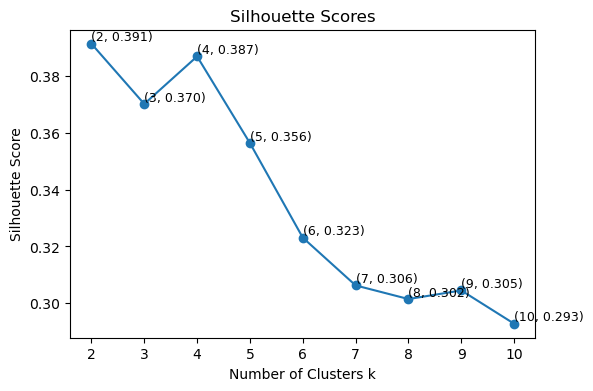

In [210]:
#plot
plt.figure(figsize=(6,4))
plt.plot(range(2,11),scores_list, marker='o')

#Loop only to place the text labels
for i, j in zip(range(2,11), scores_list):
    plt.text(i, j, f'({i}, {j:.3f})', ha='left', va='bottom', fontsize=9)

plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters k')
plt.ylabel('Silhouette Score')
plt.show()

In [456]:
#3) Best clustering K-means Model 
kmeans = KMeans(
    n_clusters=4,
    random_state=0,
    init = 'k-means++',
    n_init=10
)
#NEW FEATURE - assigns cluster label to each row
df_model['Cluster'] = kmeans.fit_predict(X_scaled)  

df_model[['log_price','average_rating','log_helpful_vote','Cluster']].head()


,log_price,average_rating,log_helpful_vote,Cluster
4,3.849935,4.0,0.000000,0
7,3.044046,4.3,2.302585,1
14,2.638343,4.7,0.000000,2
16,3.931630,4.3,0.000000,3
17,3.256172,4.6,0.000000,2


In [457]:
# Summary of k-means average features PER CLUSTER (shown in PCA plot)                              #USE FIGURE MAYBE
kmeans_cluster_summary = df_model.groupby('Cluster').mean()
kmeans_cluster_summary 


,price,average_rating,helpful_vote,rating_count,log_price,log_helpful_vote,log_rating_count,popular_product,DBSCAN_Cluster
Cluster,,,,,,,,,
0,43.062549,3.714779,0.383534,545.547694,3.343547,0.226581,4.709333,0.221524,0.422219
1,131.831675,4.285336,10.763855,1465.050025,4.013118,1.993170,6.032331,0.493870,0.871506
2,18.458233,4.489655,0.198352,2659.888709,2.825538,0.127101,6.293631,0.572490,0.292168
3,235.379553,4.365382,0.415529,2100.576573,5.032481,0.254533,6.054079,0.511111,0.516734


- popular_product = 1 or 0 if rating_count>median, here convert average
- highest rating counts were for average price of LOWEST items and HIGHEST items 
- cluster 1 had most avg helpful votes
- cluster 2 = budget cheap but most popular rated products
- cluster 3 = most expensive products, 2nd most popular rated

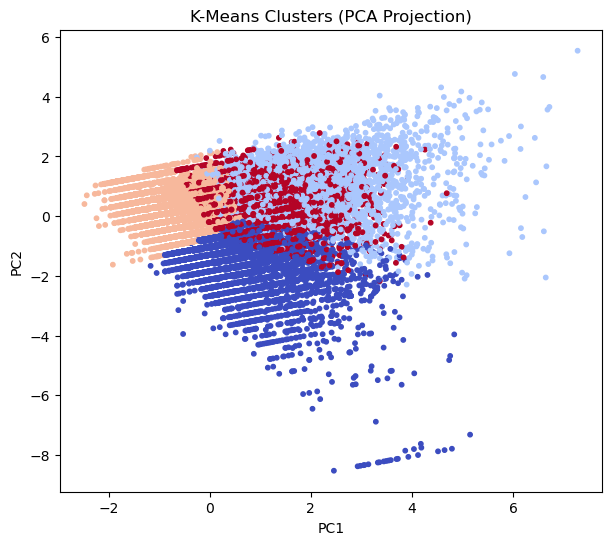

In [438]:
#4) PCA for Clustering
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

#scale features
X_pca = pca.fit_transform(X_scaled) #array only 2 components 

#Plot pca
plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],     #all rows, PC 1
    X_pca[:,1],     #all rows, PC 2
    c=df_model['Cluster'],  #color values 
    cmap='coolwarm',
    s=10    #marker size
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (PCA Projection)')
plt.show()


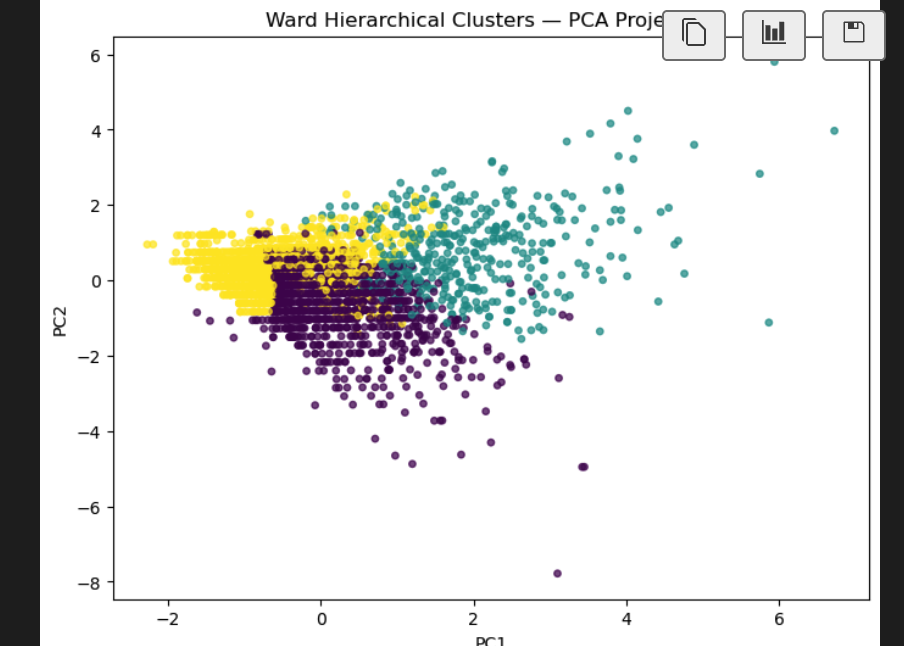

- clustering on only 3 variables so some overlap expected, harder to find very distinct groupings
- "banding" because avg_rating is discrete 0.1 intervals (4.0, 4.1, etc)
- light and dark blue clusters = separated by PC2


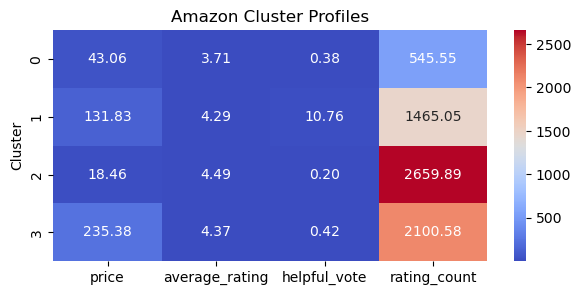

In [451]:
amazon_heat = kmeans_cluster_summary[
    ['price',
     'average_rating',
     'helpful_vote',
     'rating_count']
]

plt.figure(figsize=(7,3))

sns.heatmap(
    amazon_heat,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Amazon Cluster Profiles')
plt.ylabel('Cluster')
plt.show()

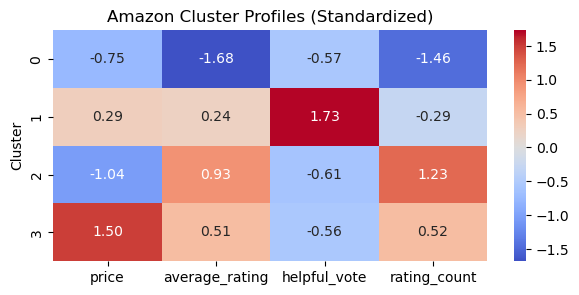

In [452]:
#amazon cluster profile heatmap                             figure maybe
from sklearn.preprocessing import StandardScaler

heat_scaled = pd.DataFrame(
    StandardScaler().fit_transform(amazon_heat),
    columns=amazon_heat.columns,
    index=amazon_heat.index
)

plt.figure(figsize=(7,3))

sns.heatmap(
    heat_scaled,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Amazon Cluster Profiles (Standardized)')
plt.ylabel('Cluster')
plt.show()

- cluster 0 = products with below-average price, and low num of reviews SIGNALS LOWEST RATINGS and less helpful votes analysis
- cluster 1 = GROUP highest prices had most helpful vote counts, also had lowest popularity reviews
- cluste 2 = ESSENTIALS, lowest prices, highest ratings and num of reviews

## Week 11 - Clustering 2
- include DBSCAN, HAC, linkage methods, dendrograms


In [410]:
#Choose best epsilon 
from sklearn.cluster import DBSCAN

for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)

    print(
        f"eps={eps}:",
        pd.Series(labels).value_counts().sort_index().to_dict()
    )

eps=0.3: {-1: 1582, 0: 28063, 1: 1809, 2: 5495, 3: 1916, 4: 868, 5: 6, 6: 9, 7: 11, 8: 2, 9: 13, 10: 7, 11: 12, 12: 7}
eps=0.5: {-1: 438, 0: 28145, 1: 5625, 2: 5552, 3: 15, 4: 6, 5: 19}
eps=0.7: {-1: 142, 0: 28167, 1: 11476, 2: 15}
eps=1.0: {-1: 49, 0: 28178, 1: 11556, 2: 17}
eps=1.5: {-1: 8, 0: 39792}


In [ ]:
#1) DBSCAN          useful for non-linear clusters

#model
dbscan = DBSCAN(
    eps=0.5,     #epsilon default min distance to be considered neighbor 
    min_samples=10
)

#predictions
dbscan_pred = dbscan.fit_predict(X_scaled)
dbscan_pred

#new feature that labels each row in a cluster
df_model['DBSCAN_Cluster'] = dbscan_pred
df_model['DBSCAN_Cluster'].sort_values(ascending=False)

416352    5
157911    5
5028      5
334002    5
428401    5
         ..
456524   -1
428379   -1
404657   -1
354063   -1
275247   -1
Name: DBSCAN_Cluster, Length: 39800, dtype: int64

- DBSCAN uses "-1" for noise or outliers

In [299]:
# 1b) Num of Clusters and Noise Points
n_noise = list(dbscan_pred).count(-1)
n_clusters = df_model['DBSCAN_Cluster'].nunique() - (1 if -1 in dbscan_pred else 0)    #since -1 present, subtract 1 from total clusters

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 6
Number of noise points: 438


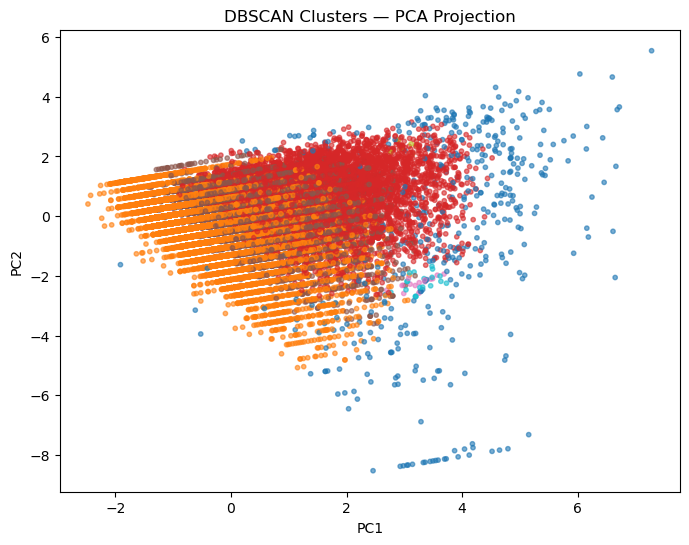

In [353]:
#1C) DBSCAN PCA plot
pca = PCA(n_components=2)
#scale
X_pca = pca.fit_transform(X_scaled)

#Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_pred,  #color values
    cmap = 'tab10',
    s=10,   #size of points
    alpha = 0.6
)

plt.title('DBSCAN Clusters — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [300]:
#1D) Test different DBSCAN parameters       (3min runtime)          USE THIS FIGURE MAYBE

dbscan_results = []

#parameters list
eps_values = [0.2,0.3,0.4,0.5,0.6]
min_sample_values = [5,10,20]

#Double for-loop 
for eps in eps_values:
    for min_samples in min_sample_values:
        #create dbscan
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
        )
        #predict cluster labels
        labels = dbscan.fit_predict(X_scaled)

        #variables for how many noise and clusters
        n_noise = list(labels).count(-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)    #since -1 present, subtract 1 from total clusters
        non_noise = labels != -1 

        #calculate silhouette score if viable
        if n_clusters >=2 and non_noise.sum() > n_clusters:     #cannot have more clusters than non_noise data points
            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise],
            )
        else:
            score = None
        
        #append results to list FOR EACH PARAMETER trial
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'noise_points': n_noise,
            'silhouette_score': score
        })

#convert results to df
dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.sort_values('silhouette_score', ascending=False)



,eps,min_samples,clusters,noise_points,silhouette_score
13,0.6,10,3,246,0.321518
14,0.6,20,2,432,0.319987
12,0.6,5,5,130,0.312290
11,0.5,20,3,782,0.203997
8,0.4,20,4,1375,0.194270
9,0.5,5,10,233,0.189034
10,0.5,10,6,438,0.177776
7,0.4,10,7,728,0.167979
4,0.3,10,13,1582,0.155599
5,0.3,20,10,2770,0.154629


In [302]:
#2) Hierarchical Agglomerative Clustering (HAC)

#create smaller sample of only 3000 
np.random.seed(0)
sample_size = 3000

#random sample only 3000 rows
hac_sample = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False   #without replacement
)

#X matrix to use for HAC
X_hac = X_scaled[hac_sample]

In [307]:
#2B) Compare Linkage Methods
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#list of methods
linkage_methods = [
    'ward',
    'complete',
    'average',
    'single'
]

hac_results = []    #empty list

#loop over each method
for method in linkage_methods:
    #CREATE HAC MODEL HERE
    hac = AgglomerativeClustering(
        n_clusters=4,
        linkage=method,
        metric='euclidean'
    )

    #find predictions
    labels = hac.fit_predict(X_hac)

    score = silhouette_score(X_hac, labels) #actual, predicted

    #append to list
    hac_results.append({
        'Linkage': method,
        'Silhouette Score': score
    })

#show results
hac_results = pd.DataFrame(hac_results)
hac_results.sort_values('Silhouette Score', ascending=False)



,Linkage,Silhouette Score
3,single,0.641013
2,average,0.477329
1,complete,0.442146
0,ward,0.262663


- single linkage (closest points in each cluster) had HIGHEST silhouette score b/c creates "long chains" of points, but NOT ALWAYS MEANINGFUL CLUSTERS analysis
- Wards is better for plotting HAC since it minimizes within-cluster variance

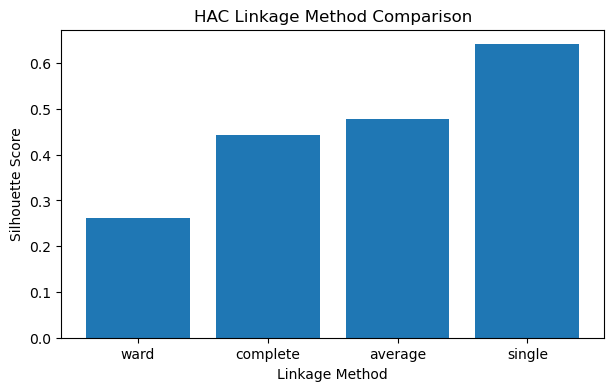

In [308]:
#2C) Plot linkage vs. sil score 
plt.figure(figsize=(7,4))

plt.bar(
    hac_results['Linkage'],
    hac_results['Silhouette Score']
)

plt.title('HAC Linkage Method Comparison')
plt.xlabel('Linkage Method')
plt.ylabel('Silhouette Score')

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2, 7):

    hac = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = hac.fit_predict(X_hac)

    results.append({
        'Clusters': k,
        'Silhouette': silhouette_score(X_hac, labels)
    })

pd.DataFrame(results) 

,Clusters,Silhouette
0,2,0.412450
1,3,0.245426
2,4,0.262663
3,5,0.272398
4,6,0.284080


- used 3 CLUSTERS B/C more distinct, ALSO WARD DENDROGRAM LATER ON matches and shows 3 clusters !

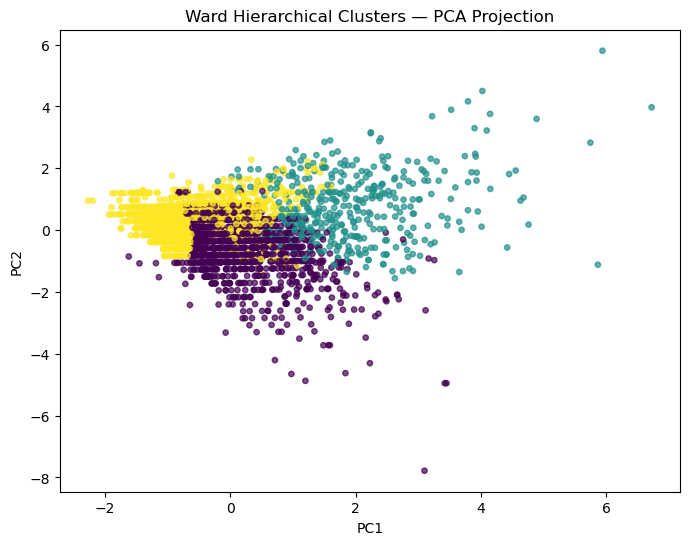

In [405]:
#2D) Fit FINAL HAC model using ward
# list = ['ward','single', 'complete', 'average'] REMEMBER others besides ward had bad PCA plots all one color

hac = AgglomerativeClustering(
    n_clusters=3,       
    linkage= 'ward'    #ward most distinct clusters
)

#find predictions 
best_hac_labels = hac.fit_predict(X_hac)

#2E) HAC PCA Plot
X_hac_pca = PCA(n_components=2).fit_transform(X_hac)

plt.figure(figsize=(8,6))

plt.scatter(
    X_hac_pca[:, 0],
    X_hac_pca[:, 1],
    c=best_hac_labels,
    cmap='viridis',
    s=15,
    alpha=0.7
)

plt.title(f'Ward Hierarchical Clusters — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

- analysis = identified 3 product groups mostly differ by PC1, distinct lower-PC2 product group in purple

- ward linkage selected for visual bc generated more distinct/interpretable clusters, single linkage had highest Sil S, but produces chaining...etc

In [325]:
#3) DENDROGRAM
from scipy.cluster.hierarchy import linkage, dendrogram

#smaller sample for dendrogram
np.random.seed(0)
my_sample = np.random.choice(
    len(X_scaled),
    size=500,
    replace=False
)

X_dendrogram = X_scaled[my_sample]

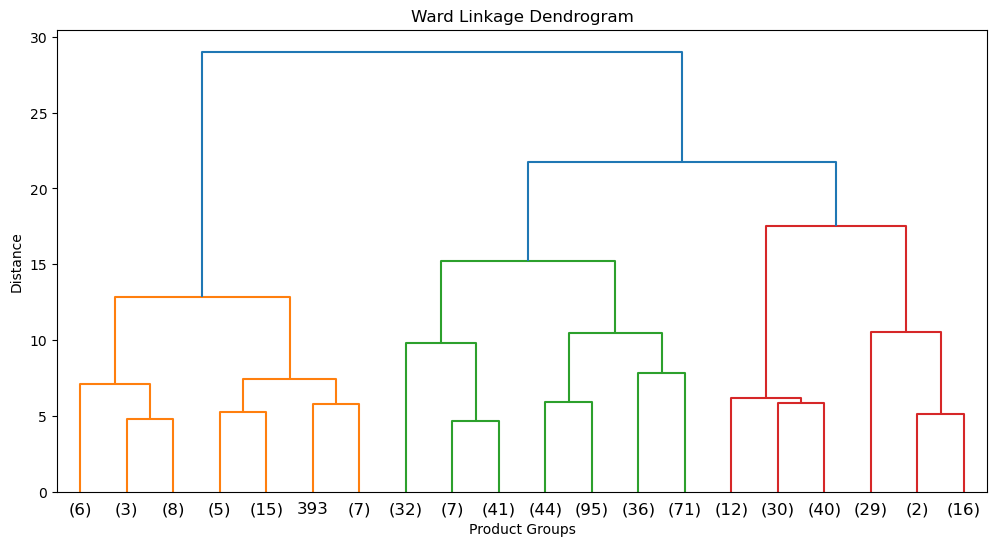

In [335]:
#3B) Ward Dendrogram

#perform HAC first to get matrix
linkage_matrix = linkage(           #output 2D array with 4 columns (cluster1, cluster2, distance_method, size of cluster)
    X_dendrogram,
    method='ward',
    metric='euclidean'
)

plt.figure(figsize=(12,6))

#create dendrogram
dendrogram(
    linkage_matrix,     #encodes the hierarchical clustering
    truncate_mode='lastp',  #last p non-singleton clusters formed in the linkage are the only non-leaf nodes
    p=20,                    
    no_labels=False
)

plt.title('Ward Linkage Dendrogram')
plt.xlabel('Product Groups')
plt.ylabel('Distance')

plt.show()

- helps decide how many clusters might be reasonable
- ALSO vertical distance jump important, larger means less similar groups (orange pretty disimilar to green/red)
note cutting tree around 18-20 would create 3 different colored clusters, SUPPORTS EARLIER K-means result ! 

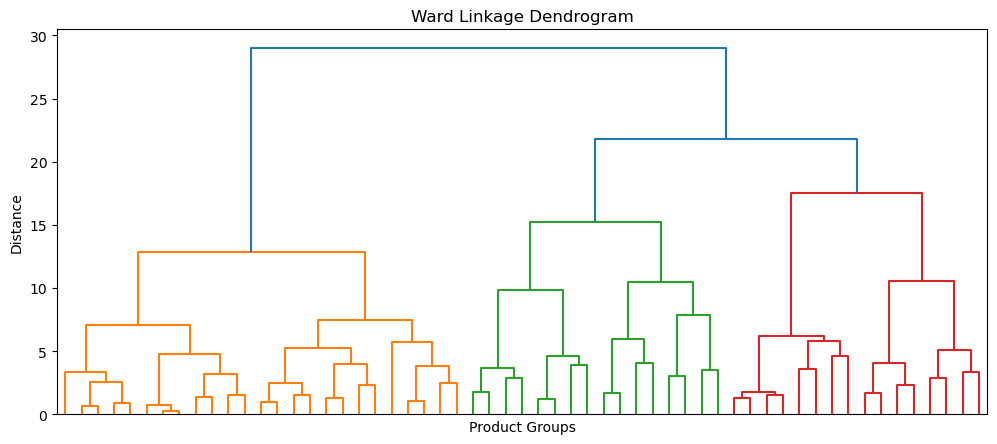

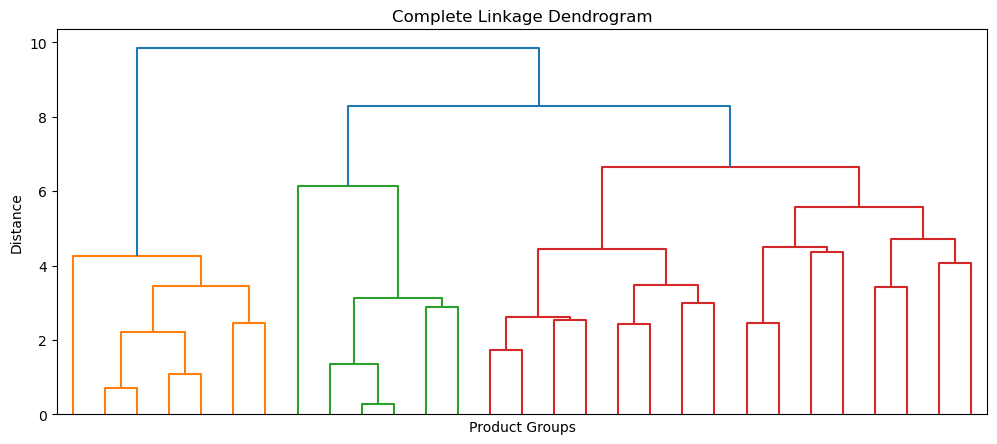

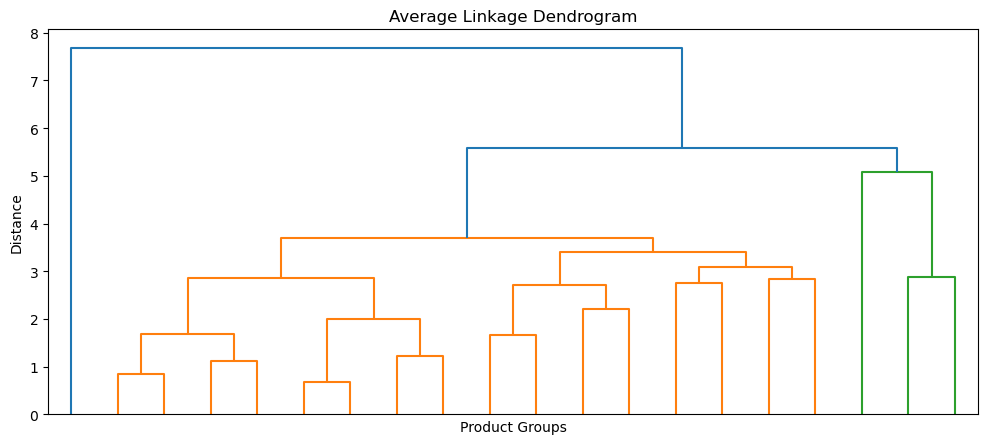

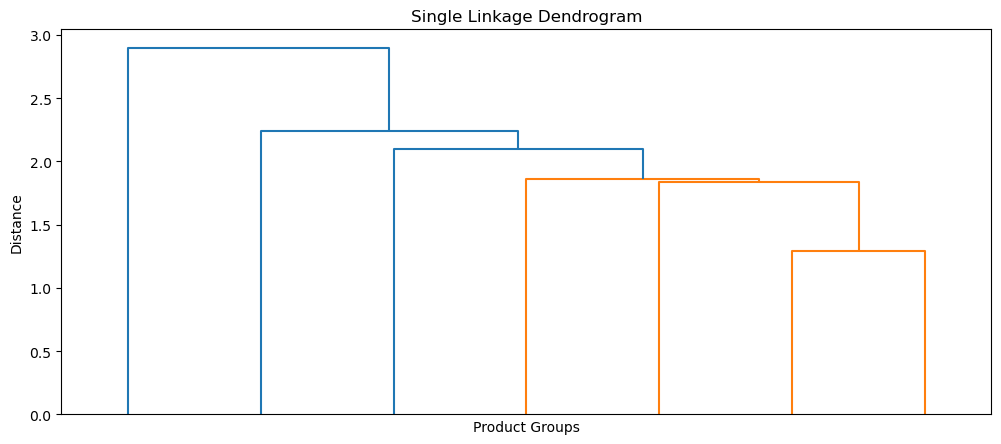

In [331]:
#3C) Compare dendrograms for each linkage method 

for method in ['ward', 'complete', 'average', 'single']:
    linkage_matrix = linkage(
        X_dendrogram,
        method=method,
        metric='euclidean'
    )

    plt.figure(figsize=(12,5))

    dendrogram(
        linkage_matrix,
        truncate_mode='level',
        p=5,
        no_labels=True
    )

    plt.title(f'{method.title()} Linkage Dendrogram')
    plt.xlabel('Product Groups')
    plt.ylabel('Distance')

    plt.show()

In [348]:
#view cluster sizes

#use best HAC model from above
hac = AgglomerativeClustering(
        n_clusters=3,       
        linkage= 'ward'    #ward most distinc clusters
    )

#find predictions 
best_hac_labels = hac.fit_predict(X_hac)


# Create dataframe for sampled products
df_hac = df_model.iloc[hac_sample].copy()

# Add cluster labels
df_hac['Ward_Cluster'] = best_hac_labels

df_hac['Ward_Cluster'].value_counts().sort_index()

Ward_Cluster
0    1173
1     411
2    1416
Name: count, dtype: int64

In [449]:
#Ward Cluster summary 
ward_cluster_summary = (
    df_hac
    .groupby('Ward_Cluster')[
        ['price',
         'average_rating',
         'helpful_vote',
         'rating_count']
    ]
    .mean()
    .round(2)
)

ward_cluster_summary

,price,average_rating,helpful_vote,rating_count
Ward_Cluster,,,,
0,76.55,4.15,0.10,1400.48
1,261.58,4.24,9.84,1322.59
2,16.24,4.51,0.48,2688.21


- report chat = K-Means table produced four relatively specific product segments, distinguishing inexpensive, premium, and luxury products as separate groups. Ward hierarchical clustering generated three broader clusters by progressively merging similar groups based on minimizing within-cluster variance. Consequently, Ward combined some of the intermediate product segments identified by K-Means into a larger cluster while preserving the distinction between inexpensive and premium products. Despite the different grouping strategies, both methods consistently identified low-priced, highly rated products and high-priced products as distinct segments.